# 🎯 Eventzella — Analyse Complète des Données
### Pipeline : Chargement → Nettoyage → EDA → Feature Selection → Visualisation
---

## 📦 0. Installation des librairies

In [6]:
!pip install openpyxl missingno -q
!pip install xgboost lightgbm catboost prophet -q

## 📂 1. Importation des librairies & Chargement des données

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
#from google.colab import files
#import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [8]:
# ── Chargement du fichier Excel depuis le projet ─────────────────────────────
from pathlib import Path

# Détection du dossier racine du projet (EventZella)
cwd = Path.cwd()
candidates = [cwd, *cwd.parents]
excel_path = None
for base in candidates:
    candidate = base / "data" / "eventzella_schema.xlsx"
    if candidate.exists():
        excel_path = candidate
        break

if excel_path is None:
    raise FileNotFoundError("eventzella_schema.xlsx introuvable. Vérifie le dossier data/ du projet EventZella.")

print(f"📄 Fichier Excel utilisé : {excel_path}")
sheets = pd.read_excel(excel_path, sheet_name=None)

# Chargement de chaque feuille dans une variable dédiée
beneficiary      = sheets["BENEFICIARY"]
provider         = sheets["PROVIDER"]
category         = sheets["CATEGORY"]
subcategory      = sheets["SUBCATEGORY"]
service          = sheets["SERVICE"]
event            = sheets["EVENT"]
reservation      = sheets["RESERVATION"]
evaluation       = sheets["EVALUATION"]
complaint        = sheets["COMPLAINT"]
visitors         = sheets["VISITORS"]
marketing        = sheets["MARKETING_SPEND"]

print("✅ Toutes les feuilles chargées !")
for name, df in sheets.items():
    print(f"  📄 {name:20s} → {df.shape[0]:6d} lignes × {df.shape[1]} colonnes")

📄 Fichier Excel utilisé : c:\Users\chari\.gemini\antigravity\scratch\EventZella\data\eventzella_schema.xlsx
✅ Toutes les feuilles chargées !
  📄 BENEFICIARY          →   5000 lignes × 5 colonnes
  📄 PROVIDER             →    800 lignes × 6 colonnes
  📄 CATEGORY             →      4 lignes × 2 colonnes
  📄 SUBCATEGORY          →      4 lignes × 3 colonnes
  📄 SERVICE              →   2500 lignes × 6 colonnes
  📄 EVENT                →  12000 lignes × 6 colonnes
  📄 RESERVATION          →  18000 lignes × 6 colonnes
  📄 EVALUATION           →  12000 lignes × 4 colonnes
  📄 COMPLAINT            →   2500 lignes × 6 colonnes
  📄 VISITORS             →    365 lignes × 4 colonnes
  📄 MARKETING_SPEND      →     36 lignes × 4 colonnes


## 🔍 2. Aperçu général des données (Data Overview)

In [9]:
# ── Aperçu de chaque table ───────────────────────────────────────────────────
for name, df in sheets.items():
    print(f'\n{'='*60}')
    print(f'📋 TABLE : {name}')
    print(f'{'='*60}')
    display(df.head(3))
    print('\nTypes de données :')
    print(df.dtypes)


📋 TABLE : BENEFICIARY


,id_beneficiary,first_name,last_name,email,phone
0,1,Derek,Lara,NaN,21620426159
1,2,Lori,Wu,heatherlopez@example.com,21658030013
2,3,Holly,Haas,xsanders@example.net,21675668113



Types de données :
id_beneficiary     int64
first_name        object
last_name         object
email             object
phone              int64
dtype: object

📋 TABLE : PROVIDER


,id_provider,name,service_type,email,phone,city
0,1,Cooper-Lloyd,Decoration,williamsrobert@sutton.org,21675694650,Jendouba
1,2,"Andrews, Hart and Smith",Decoration,zturner@watson.info,21676863739,Kébili
2,3,Gutierrez LLC,Decoration,ashley04@haney.com,21642179254,Kairouan



Types de données :
id_provider      int64
name            object
service_type    object
email           object
phone            int64
city            object
dtype: object

📋 TABLE : CATEGORY


...


Types de données :
id_complaint       int64
description       object
status            object
id_beneficiary     int64
id_provider        int64
subject           object
dtype: object

📋 TABLE : VISITORS


,id,date,visitors,reservations
0,93,03/01/2022 17:30:26,3538,185
1,187,06/01/2022 06:52:24,595,147
2,86,11/01/2022 23:55:58,4016,130



Types de données :
id               int64
date            object
visitors         int64
reservations     int64
dtype: object

📋 TABLE : MARKETING_SPEND


,id,month,marketing_spend,new_beneficiaries
0,1,2023-01-01 00:00:00,29217,1568
1,2,2023-02-01 00:00:00,142420,1166
2,3,2023-03-01 00:00:00,24307,1488



Types de données :
id                    int64
month                object
marketing_spend       int64
new_beneficiaries     int64
dtype: object


In [10]:
# ── Statistiques descriptives des colonnes numériques ───────────────────────
for name, df in sheets.items():
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\n📊 {name} — Statistiques numériques :')
        display(df[num_cols].describe().round(2))


📊 BENEFICIARY — Statistiques numériques :


,id_beneficiary,phone
count,5000.00,5.000000e+03
mean,2500.50,2.165529e+10
std,1443.52,2.429937e+07
min,1.00,2.162003e+10
25%,1250.75,2.163488e+10
50%,2500.50,2.164972e+10
75%,3750.25,2.167569e+10
max,5000.00,2.169999e+10



📊 PROVIDER — Statistiques numériques :


,id_provider,phone
count,800.00,8.000000e+02
mean,400.50,2.165603e+10
std,231.08,2.407824e+07
min,1.00,2.162002e+10
25%,200.75,2.163586e+10
50%,400.50,2.165111e+10
75%,600.25,2.167551e+10
max,800.00,2.169990e+10



📊 CATEGORY — Statistiques numériques :


...

,id_complaint,id_beneficiary,id_provider
count,2500.00,2500.00,2500.00
mean,1250.50,2496.55,406.11
std,721.83,1435.69,233.54
min,1.00,1.00,1.00
25%,625.75,1279.75,199.75
50%,1250.50,2466.50,411.00
75%,1875.25,3741.75,614.25
max,2500.00,4999.00,800.00



📊 VISITORS — Statistiques numériques :


,id,visitors,reservations
count,365.00,365.00,365.00
mean,183.00,2784.07,143.99
std,105.51,2641.68,83.19
min,1.00,58.00,0.00
25%,92.00,1141.00,70.00
50%,183.00,2505.00,143.00
75%,274.00,3679.00,208.00
max,365.00,22215.00,300.00



📊 MARKETING_SPEND — Statistiques numériques :


,id,marketing_spend,new_beneficiaries
count,36.00,36.00,36.00
mean,18.50,20977.67,1131.83
std,10.54,23632.22,573.65
min,1.00,2669.00,75.00
25%,9.75,10508.75,802.75
50%,18.50,15930.00,1248.00
75%,27.25,24619.75,1547.00
max,36.00,142420.00,1982.00


## 🧹 3. Nettoyage des données (Data Cleaning)
### 3.1 — Valeurs manquantes (Missing Values)

In [11]:
# ── Résumé global des valeurs manquantes ────────────────────────────────────
print('🔎 VALEURS MANQUANTES PAR TABLE\n')
for name, df in sheets.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    summary = pd.DataFrame({'Manquants': missing, '% Manquant': missing_pct})
    summary = summary[summary['Manquants'] > 0]
    if not summary.empty:
        print(f'\n📄 {name}')
        display(summary)

🔎 VALEURS MANQUANTES PAR TABLE


📄 BENEFICIARY


,Manquants,% Manquant
last_name,348,6.96
email,400,8.00



📄 PROVIDER


,Manquants,% Manquant
email,67,8.38



📄 SERVICE


,Manquants,% Manquant
price,214,8.56
title,349,13.96



📄 EVALUATION


,Manquants,% Manquant
comment,312,2.6


In [12]:
# ── Visualisation matrice des valeurs manquantes ─────────────────────────────
tables_with_missing = ['BENEFICIARY', 'PROVIDER', 'SERVICE', 'EVALUATION']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(tables_with_missing):
    msno.matrix(sheets[name], ax=axes[i], sparkline=False, fontsize=10, color=(0.27, 0.52, 0.71))
    axes[i].set_title(f'Missing Values — {name}', fontsize=13, fontweight='bold')

plt.suptitle('Matrice des Valeurs Manquantes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('missing_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

ImportError: cannot import name 'LoadFlags' from 'matplotlib.ft2font' (c:\Users\chari\anaconda3\Lib\site-packages\matplotlib\ft2font.cp312-win_amd64.pyd)

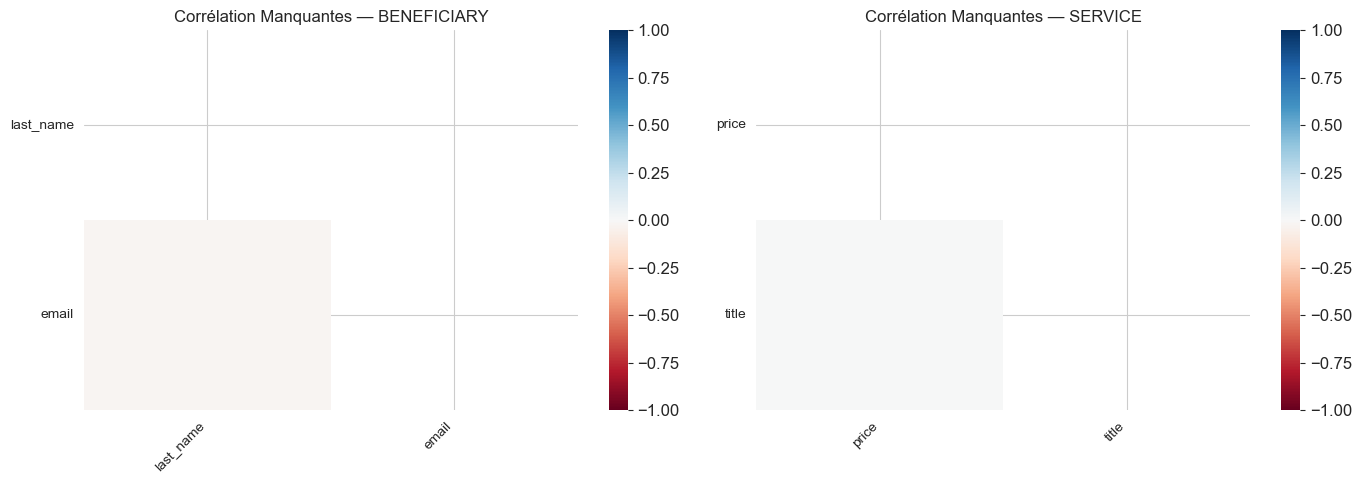

In [ ]:
# ── Heatmap des valeurs manquantes ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['BENEFICIARY', 'SERVICE']):
    msno.heatmap(sheets[name], ax=ax, fontsize=10)
    ax.set_title(f'Corrélation Manquantes — {name}', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 — Traitement des valeurs manquantes

In [ ]:
# ── Copies de travail
ben   = beneficiary.copy()
prov  = provider.copy()
svc   = service.copy()
evl   = evaluation.copy()

# BENEFICIARY : last_name (6.96%) → 'Unknown' | email (8%) → 'no_email@unknown.com'
ben['last_name'].fillna('Unknown', inplace=True)
ben['email'].fillna('no_email@unknown.com', inplace=True)

# PROVIDER : email (8.375%) → 'no_email@provider.com'
prov['email'].fillna('no_email@provider.com', inplace=True)

# SERVICE : price (8.56%) → médiane par subcategory | title (13.96%) → 'No Title'
svc['price'] = svc.groupby('id_subcategory')['price'].transform(
    lambda x: x.fillna(x.median())
)
svc['price'].fillna(svc['price'].median(), inplace=True)  # Fallback global
svc['title'].fillna('No Title', inplace=True)

# EVALUATION : comment (2.6%) → 'No Comment'
evl['comment'].fillna('No Comment', inplace=True)

# Vérification
print('✅ Vérification après traitement :')
for name, df in [('BENEFICIARY', ben), ('PROVIDER', prov), ('SERVICE', svc), ('EVALUATION', evl)]:
    total_missing = df.isnull().sum().sum()
    print(f'  {name:15s} → {total_missing} valeurs manquantes restantes')

✅ Vérification après traitement :
  BENEFICIARY     → 0 valeurs manquantes restantes
  PROVIDER        → 0 valeurs manquantes restantes
  SERVICE         → 0 valeurs manquantes restantes
  EVALUATION      → 0 valeurs manquantes restantes


### 3.3 — Valeurs aberrantes / Outliers

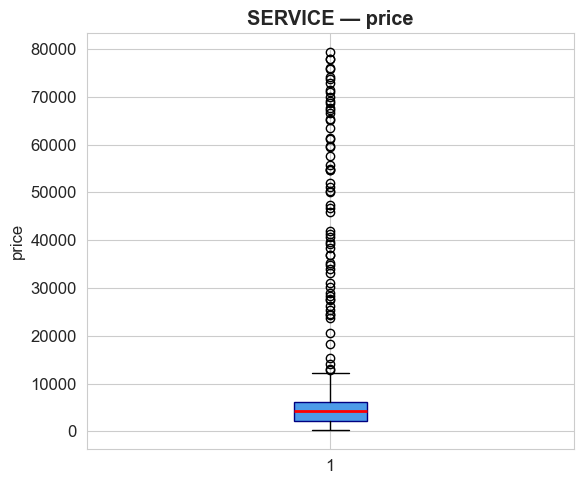

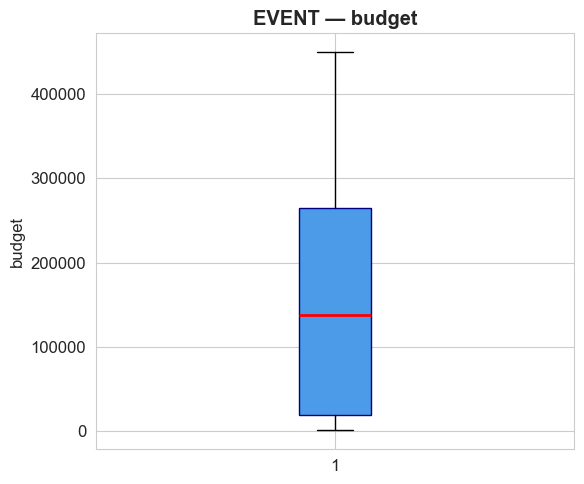

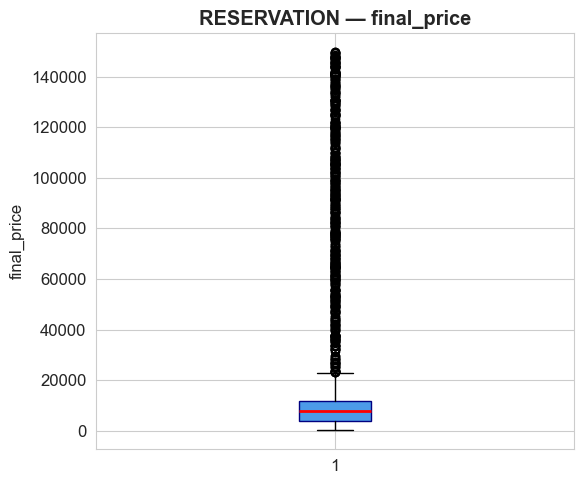

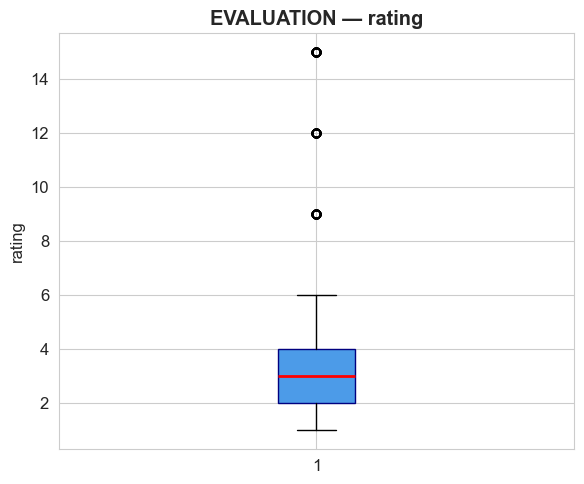

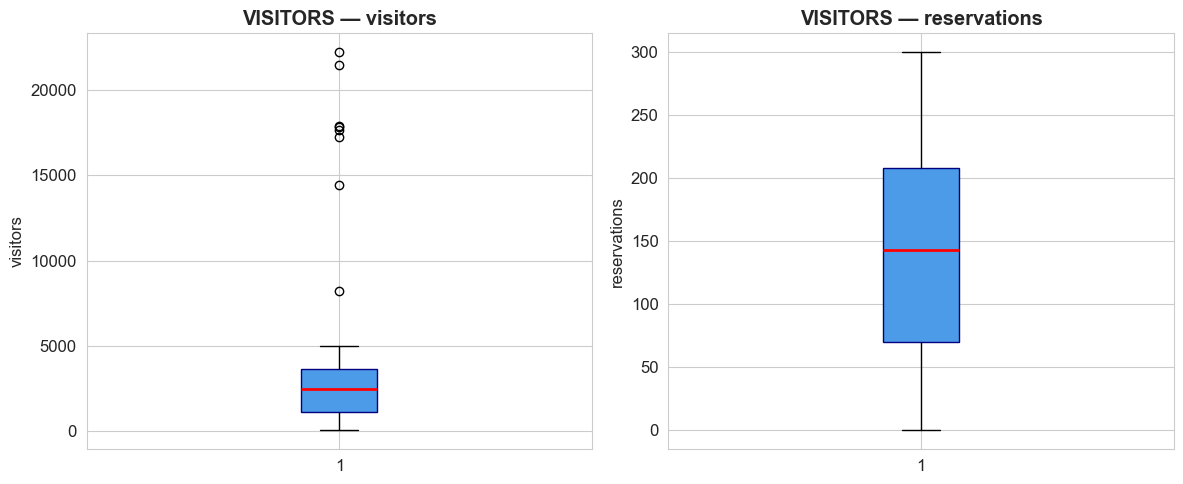

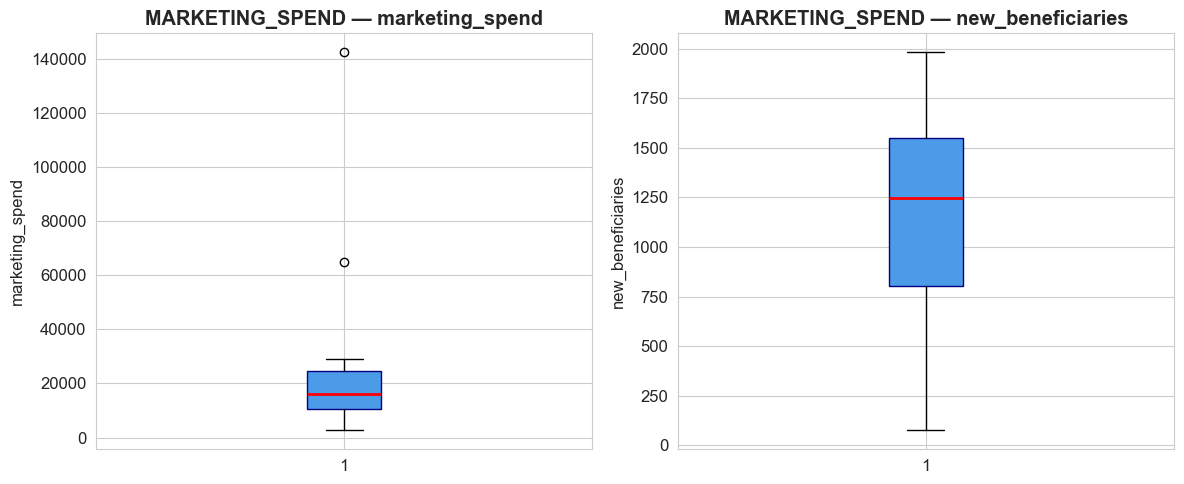

In [ ]:
# ── Boxplots pour détecter les outliers ─────────────────────────────────────
outlier_cols = {
    'SERVICE'    : ['price'],
    'EVENT'      : ['budget'],
    'RESERVATION': ['final_price'],
    'EVALUATION' : ['rating'],
    'VISITORS'   : ['visitors', 'reservations'],
    'MARKETING_SPEND': ['marketing_spend', 'new_beneficiaries']
}

for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    fig, axes = plt.subplots(1, len(cols), figsize=(6*len(cols), 5))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ax.boxplot(df_temp[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#4C9BE8', color='navy'),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(f'{table_name} — {col}', fontweight='bold')
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.savefig(f'boxplot_{table_name}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [ ]:
# ── Détection des outliers par méthode IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

print('📊 RÉSUMÉ DES OUTLIERS (méthode IQR)\n')
for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    for col in cols:
        outliers, low, up = detect_outliers_iqr(df_temp.dropna(subset=[col]), col)
        pct = len(outliers) / len(df_temp) * 100
        print(f'  {table_name}.{col:20s} → {len(outliers):5d} outliers ({pct:.1f}%)  |  Seuils: [{low:.0f}, {up:.0f}]')

📊 RÉSUMÉ DES OUTLIERS (méthode IQR)

  SERVICE.price                →    64 outliers (2.6%)  |  Seuils: [-3962, 12277]
  EVENT.budget               →     0 outliers (0.0%)  |  Seuils: [-350124, 633657]
  RESERVATION.final_price          →   495 outliers (2.8%)  |  Seuils: [-7521, 23121]
  EVALUATION.rating               →   228 outliers (1.9%)  |  Seuils: [-1, 7]
  VISITORS.visitors             →     8 outliers (2.2%)  |  Seuils: [-2666, 7486]
  VISITORS.reservations         →     0 outliers (0.0%)  |  Seuils: [-137, 415]
  MARKETING_SPEND.marketing_spend      →     2 outliers (5.6%)  |  Seuils: [-10658, 45786]
  MARKETING_SPEND.new_beneficiaries    →     0 outliers (0.0%)  |  Seuils: [-314, 2663]


In [ ]:
# ── Détection des outliers par Z-Score
print('📊 OUTLIERS PAR Z-SCORE (|z| > 3)\n')
for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    for col in cols:
        data = df_temp[col].dropna()
        z_scores = np.abs(stats.zscore(data))
        n_outliers = (z_scores > 3).sum()
        pct = n_outliers / len(data) * 100
        print(f'  {table_name}.{col:20s} → {n_outliers:5d} outliers ({pct:.1f}%)')

📊 OUTLIERS PAR Z-SCORE (|z| > 3)

  SERVICE.price                →    49 outliers (2.1%)
  EVENT.budget               →     0 outliers (0.0%)
  RESERVATION.final_price          →   387 outliers (2.1%)
  EVALUATION.rating               →   228 outliers (1.9%)
  VISITORS.visitors             →     7 outliers (1.9%)
  VISITORS.reservations         →     0 outliers (0.0%)
  MARKETING_SPEND.marketing_spend      →     1 outliers (2.8%)
  MARKETING_SPEND.new_beneficiaries    →     0 outliers (0.0%)


In [ ]:
# Traitement des outliers
# SERVICE.price : plafonner à 99e percentile (winsorisation)
svc_clean = svc.copy()
p99_price = svc_clean['price'].quantile(0.99)
svc_clean['price'] = svc_clean['price'].clip(upper=p99_price)
print(f'SERVICE price plafonné à : {p99_price:.0f} TND')

# EVALUATION.rating : rating max = 5 → supprimer les lignes > 5
evl_clean = evl.copy()
nb_invalid_rating = (evl_clean['rating'] > 5).sum()
evl_clean = evl_clean[evl_clean['rating'] <= 5]
print(f'EVALUATION : {nb_invalid_rating} ratings > 5 supprimés')

# RESERVATION.final_price : winsorisation à 99e percentile
res_clean = reservation.copy()
p99_res = res_clean['final_price'].quantile(0.99)
res_clean['final_price'] = res_clean['final_price'].clip(upper=p99_res)
print(f'RESERVATION final_price plafonné à : {p99_res:.0f} TND')

# VISITORS.visitors : winsorisation à 99e percentile
vis_clean = visitors.copy()
p99_vis = vis_clean['visitors'].quantile(0.99)
vis_clean['visitors'] = vis_clean['visitors'].clip(upper=p99_vis)
print(f'VISITORS visitors plafonné à : {p99_vis:.0f}')

# MARKETING_SPEND.marketing_spend : winsorisation
mkt_clean = marketing.copy()
p99_mkt = mkt_clean['marketing_spend'].quantile(0.99)
mkt_clean['marketing_spend'] = mkt_clean['marketing_spend'].clip(upper=p99_mkt)
print(f'MARKETING spend plafonné à : {p99_mkt:.0f} TND')

print('\n Traitement des outliers terminé !')

SERVICE price plafonné à : 54937 TND
EVALUATION : 312 ratings > 5 supprimés
RESERVATION final_price plafonné à : 104921 TND
VISITORS visitors plafonné à : 17727
MARKETING spend plafonné à : 115267 TND

 Traitement des outliers terminé !


### 3.4 — Correction des types & Doublons

In [ ]:
#Conversion des dates
res_clean_dates = res_clean.copy()
vis_clean_dates = vis_clean.copy()
event_clean = event.copy()
event_clean['event_date']             = pd.to_datetime(event_clean['event_date'], errors='coerce')
res_clean_dates['reservation_date']   = pd.to_datetime(res_clean_dates['reservation_date'], errors='coerce')
vis_clean_dates['date']               = pd.to_datetime(vis_clean_dates['date'], errors='coerce')

# Extraction de features temporelles pour EVENT
event_clean['year']    = event_clean['event_date'].dt.year
event_clean['month']   = event_clean['event_date'].dt.month
event_clean['weekday'] = event_clean['event_date'].dt.day_name()
event_clean['quarter'] = event_clean['event_date'].dt.quarter

print('✅ Dates converties et features temporelles créées')
display(event_clean[['event_date', 'year', 'month', 'quarter', 'weekday']].head())

✅ Dates converties et features temporelles créées


,event_date,year,month,quarter,weekday
0,2022-04-01 00:12:37,2022.0,4.0,2.0,Friday
1,2022-04-01 00:22:33,2022.0,4.0,2.0,Friday
2,2022-04-01 00:36:12,2022.0,4.0,2.0,Friday
3,2022-04-01 00:43:37,2022.0,4.0,2.0,Friday
4,2022-04-01 00:55:02,2022.0,4.0,2.0,Friday


In [ ]:
# ── Vérification des doublons ─────────────────────────────────────────────────
print('🔎 DOUBLONS PAR TABLE :')
for name, df in sheets.items():
    n_dup = df.duplicated().sum()
    status = '⚠️' if n_dup > 0 else '✅'
    print(f'  {status} {name:20s} → {n_dup} doublons')

🔎 DOUBLONS PAR TABLE :
  ✅ BENEFICIARY          → 0 doublons
  ✅ PROVIDER             → 0 doublons
  ✅ CATEGORY             → 0 doublons
  ✅ SUBCATEGORY          → 0 doublons
  ✅ SERVICE              → 0 doublons
  ✅ EVENT                → 0 doublons
  ✅ RESERVATION          → 0 doublons
  ✅ EVALUATION           → 0 doublons
  ✅ COMPLAINT            → 0 doublons
  ✅ VISITORS             → 0 doublons
  ✅ MARKETING_SPEND      → 0 doublons


## 📊 4. Analyse Exploratoire (EDA)
### 4.1 — Variables catégorielles

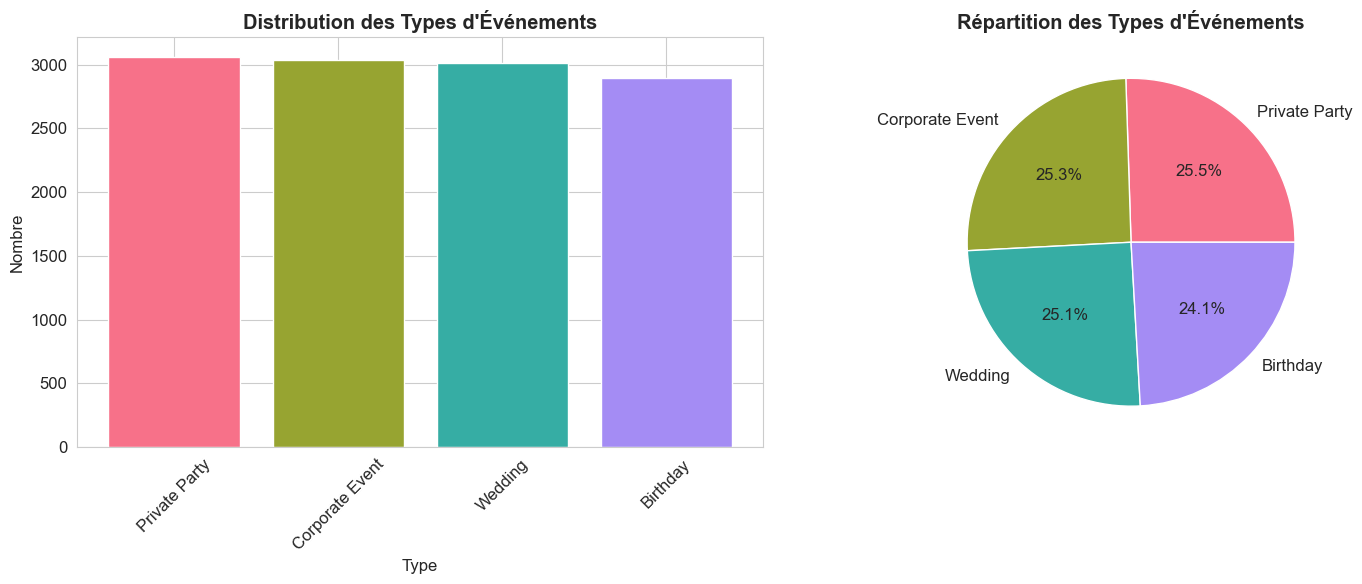

In [ ]:
# ── Distribution des types d'événements ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

event_type_counts = event_clean['type'].value_counts()
axes[0].bar(event_type_counts.index, event_type_counts.values,
            color=sns.color_palette('husl', len(event_type_counts)))
axes[0].set_title('Distribution des Types d\'Événements', fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(event_type_counts.values, labels=event_type_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('husl', len(event_type_counts)))
axes[1].set_title('Répartition des Types d\'Événements', fontweight='bold')

plt.tight_layout()
plt.savefig('event_types.png', bbox_inches='tight', dpi=150)
plt.show()

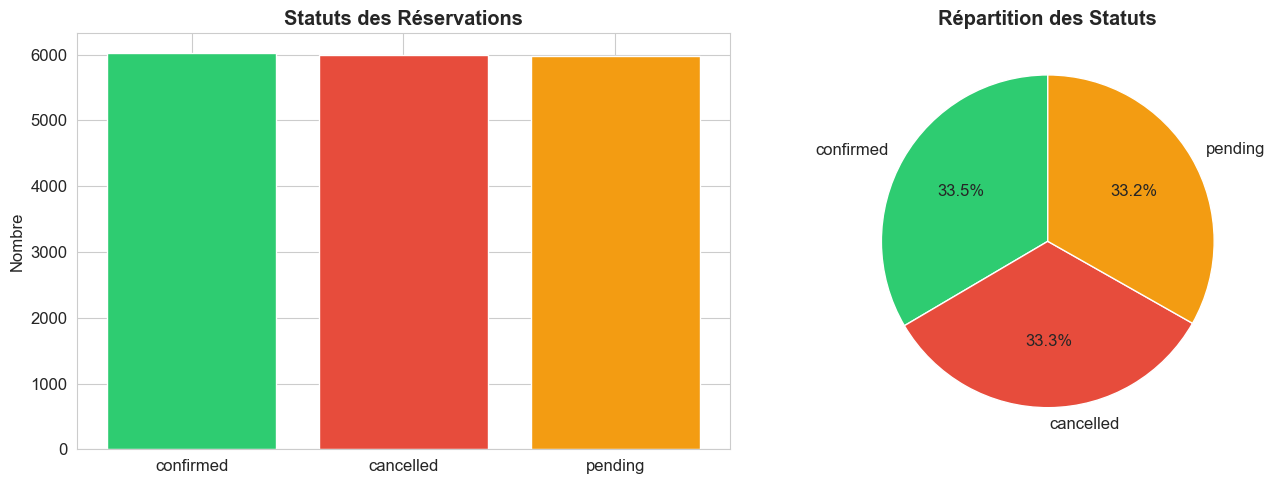

In [ ]:
# ── Statuts des réservations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_status = res_clean_dates['status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']

axes[0].bar(res_status.index, res_status.values, color=colors)
axes[0].set_title('Statuts des Réservations', fontweight='bold')
axes[0].set_ylabel('Nombre')

axes[1].pie(res_status.values, labels=res_status.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Répartition des Statuts', fontweight='bold')

plt.tight_layout()
plt.savefig('reservation_status.png', bbox_inches='tight', dpi=150)
plt.show()

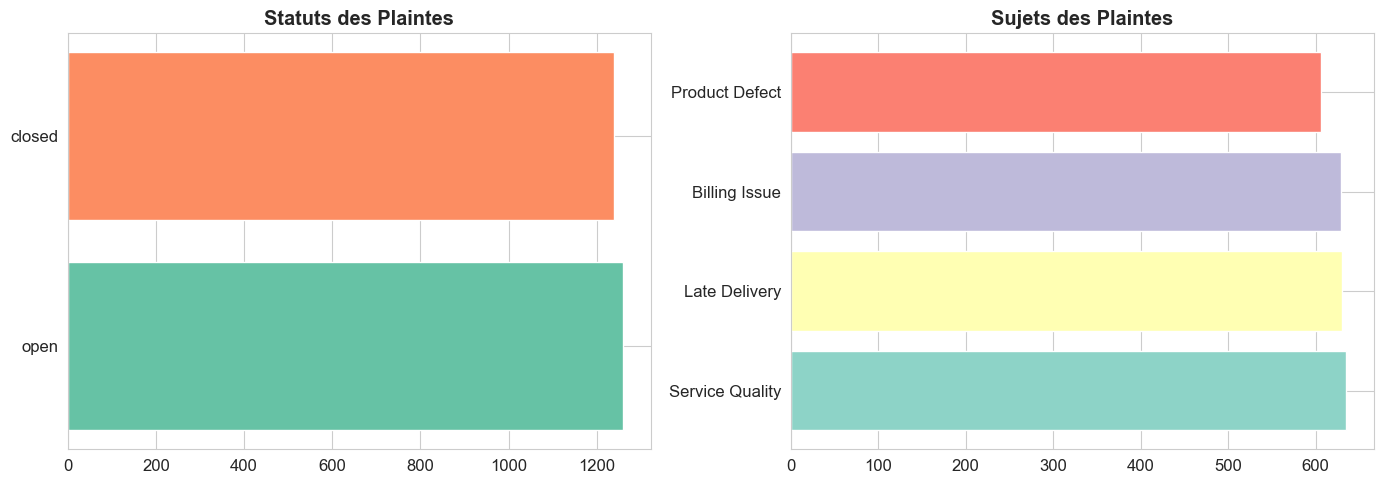

In [ ]:
#Statuts des plaintes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_status = complaint['status'].value_counts()
comp_subject = complaint['subject'].value_counts()

axes[0].barh(comp_status.index, comp_status.values,
             color=sns.color_palette('Set2', len(comp_status)))
axes[0].set_title('Statuts des Plaintes', fontweight='bold')

axes[1].barh(comp_subject.index, comp_subject.values,
             color=sns.color_palette('Set3', len(comp_subject)))
axes[1].set_title('Sujets des Plaintes', fontweight='bold')

plt.tight_layout()
plt.savefig('complaints.png', bbox_inches='tight', dpi=150)
plt.show()

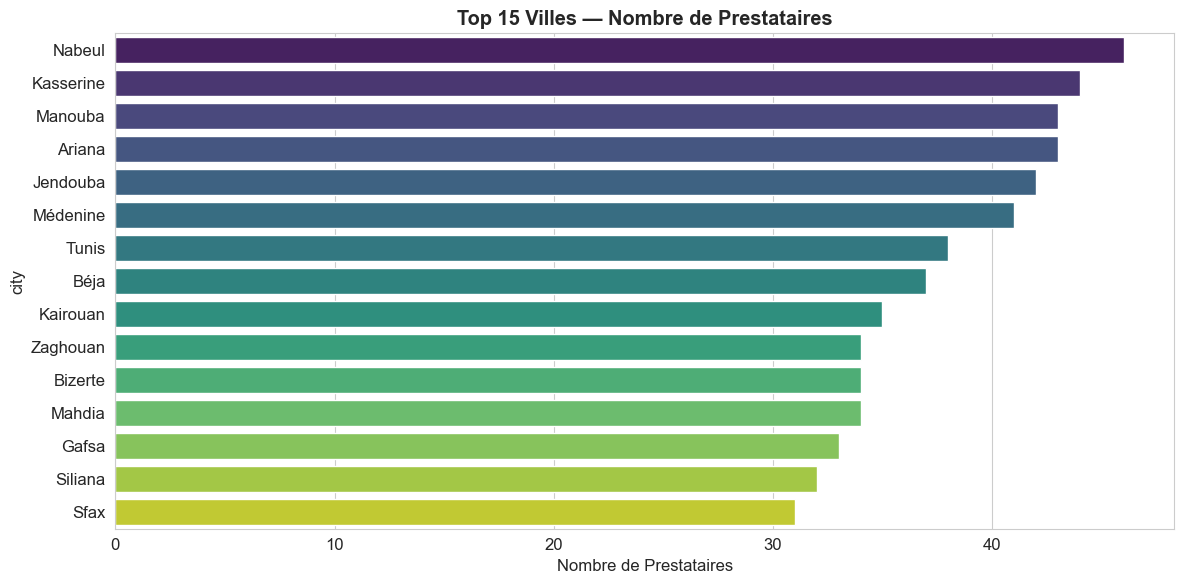

In [ ]:
#Répartition des prestataires par ville
top_cities = provider['city'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 15 Villes — Nombre de Prestataires', fontweight='bold')
plt.xlabel('Nombre de Prestataires')
plt.tight_layout()
plt.savefig('provider_cities.png', bbox_inches='tight', dpi=150)
plt.show()

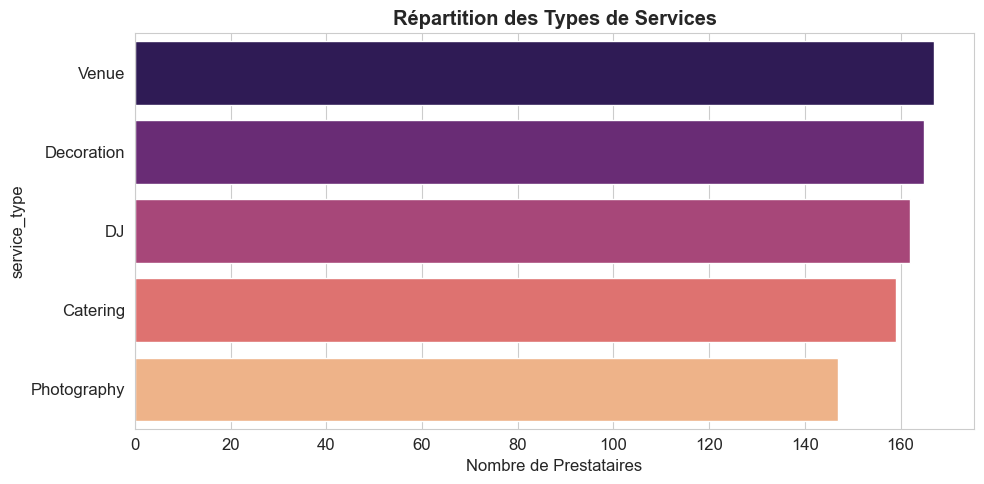

In [ ]:
#Types de services des prestataires
service_types = provider['service_type'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=service_types.values, y=service_types.index, palette='magma')
plt.title('Répartition des Types de Services', fontweight='bold')
plt.xlabel('Nombre de Prestataires')
plt.tight_layout()
plt.savefig('service_types.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 — Variables numériques

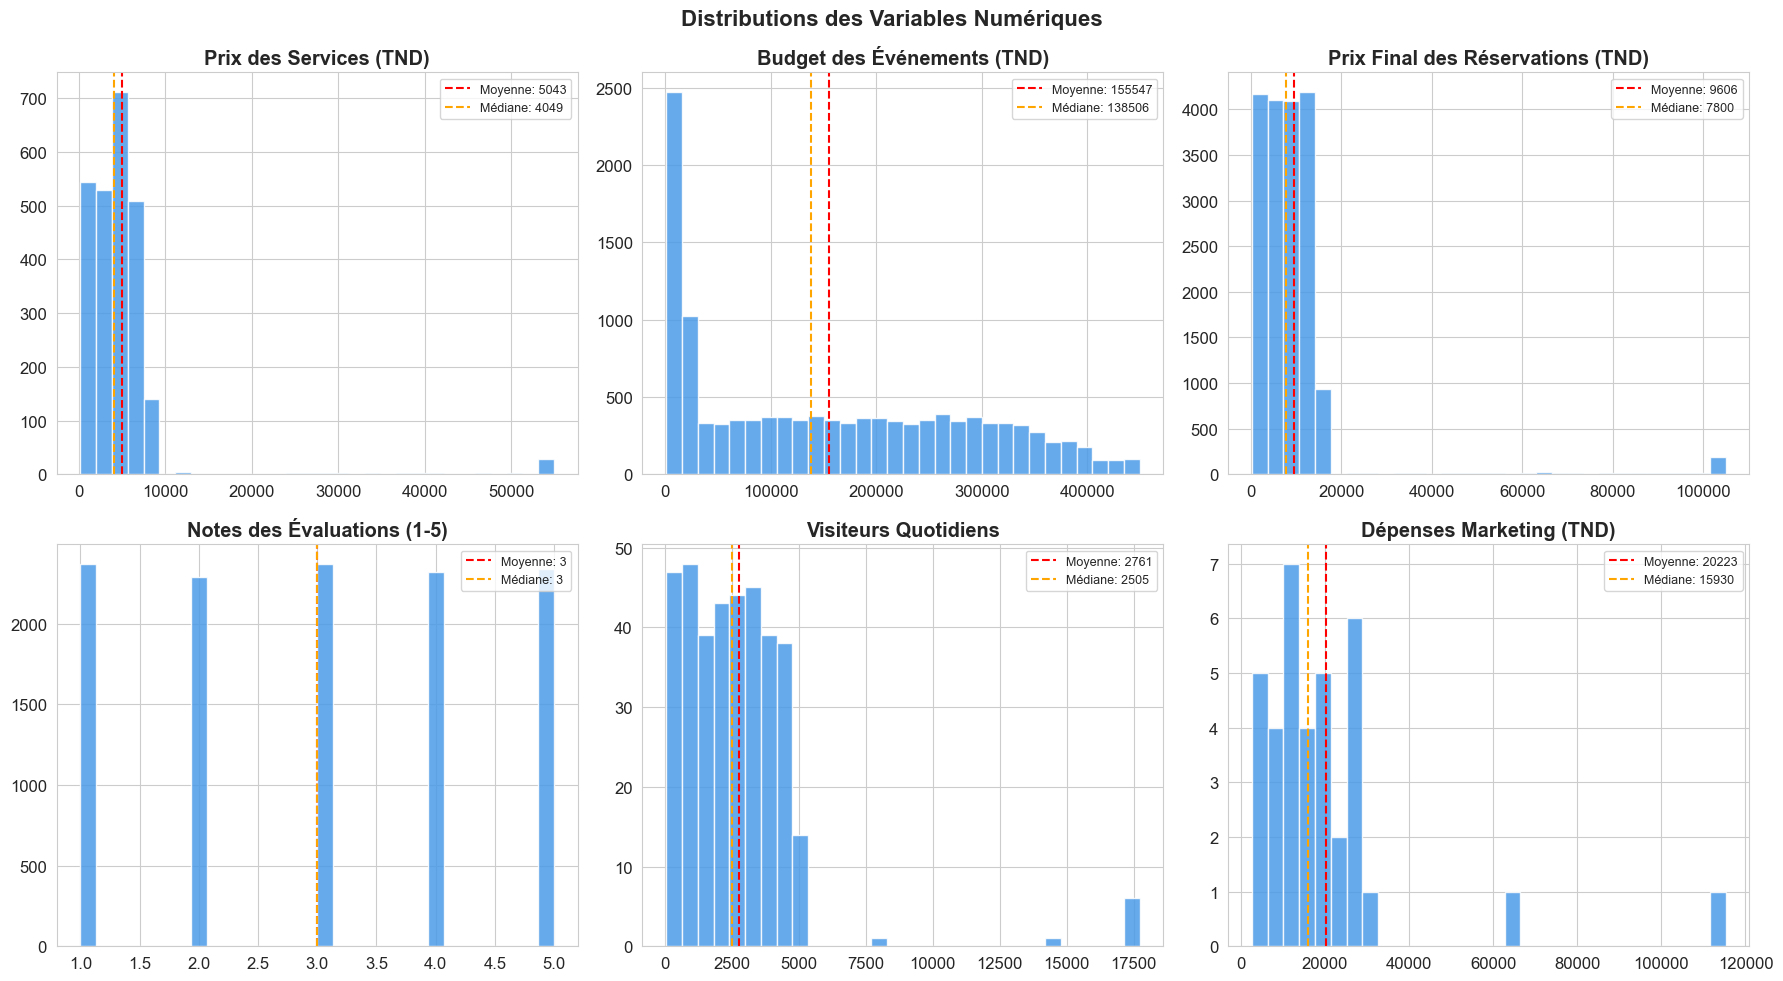

In [ ]:
#Distributions des variables numériques clés
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_distributions = [
    (svc_clean, 'price', 'Prix des Services (TND)'),
    (event_clean, 'budget', 'Budget des Événements (TND)'),
    (res_clean, 'final_price', 'Prix Final des Réservations (TND)'),
    (evl_clean, 'rating', 'Notes des Évaluations (1-5)'),
    (vis_clean, 'visitors', 'Visiteurs Quotidiens'),
    (mkt_clean, 'marketing_spend', 'Dépenses Marketing (TND)'),
]

for ax, (df_t, col, title) in zip(axes, num_distributions):
    data = df_t[col].dropna()
    ax.hist(data, bins=30, color='#4C9BE8', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Médiane: {data.median():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distributions des Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_numeriques.png', bbox_inches='tight', dpi=150)
plt.show()

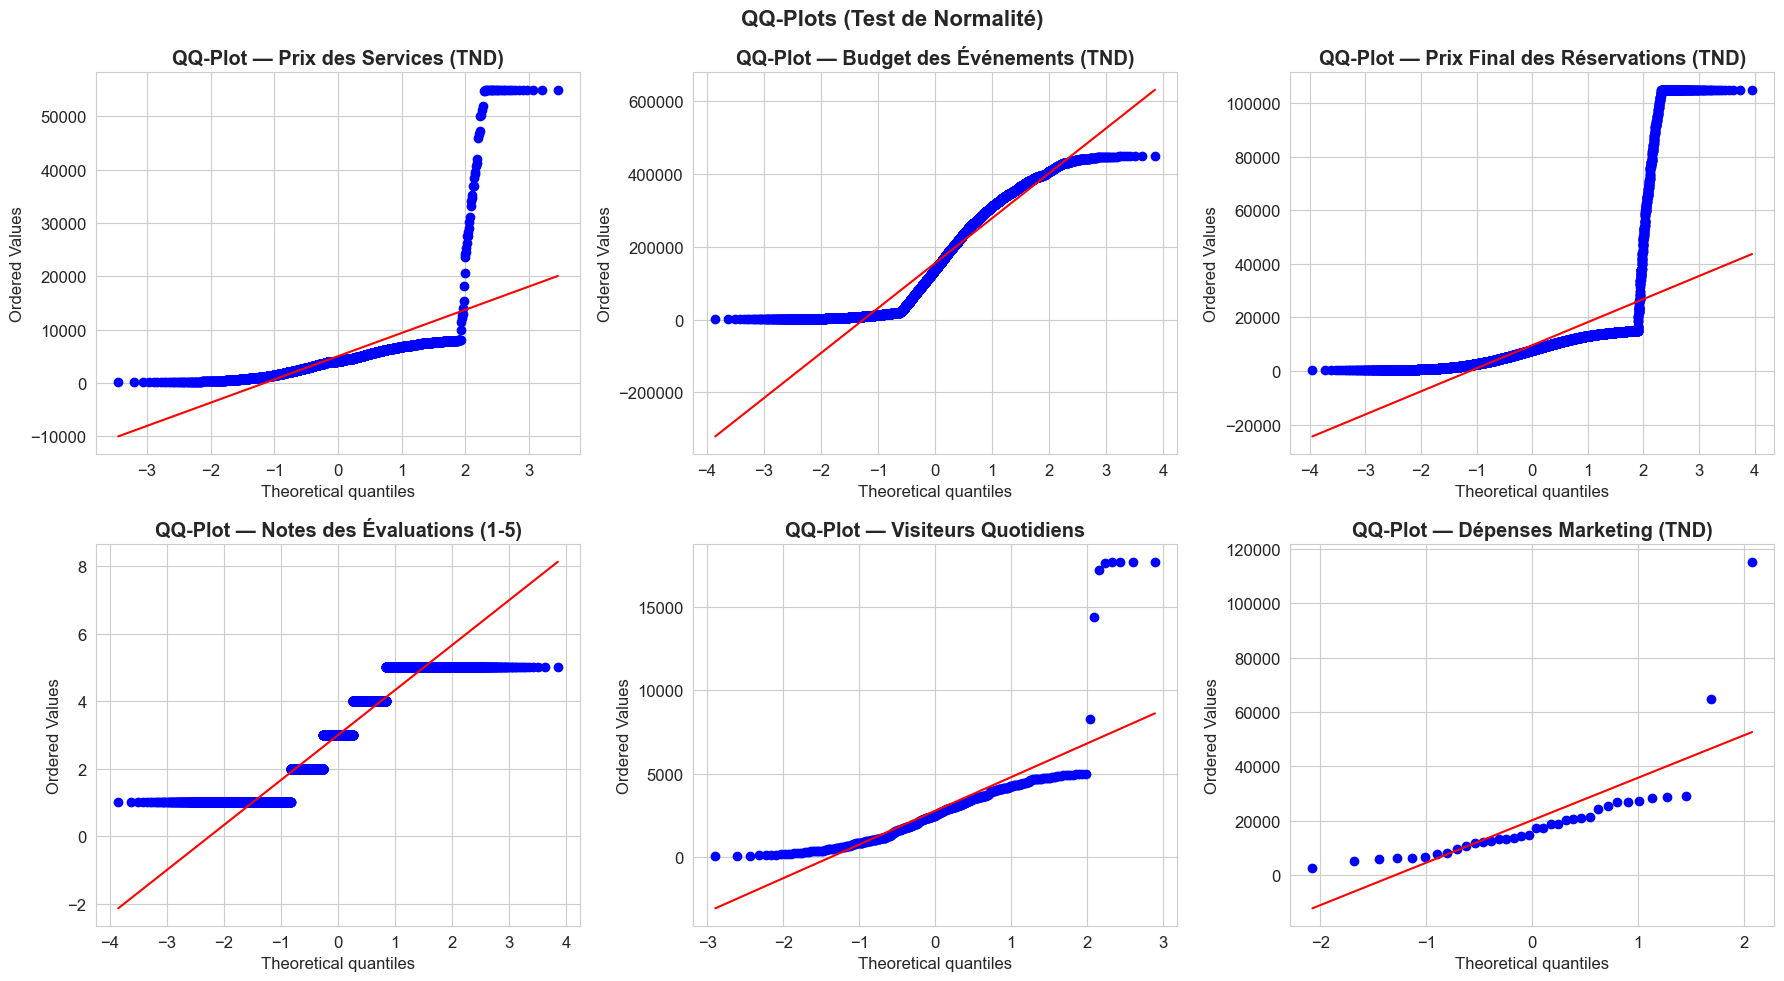

In [ ]:
# QQ-Plots pour tester la normalité
from scipy.stats import probplot

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (df_t, col, title) in zip(axes, num_distributions):
    data = df_t[col].dropna()
    probplot(data, dist='norm', plot=ax)
    ax.set_title(f'QQ-Plot — {title}', fontweight='bold')

plt.suptitle('QQ-Plots (Test de Normalité)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('qqplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Tests de Shapiro-Wilk (normalité)
from scipy.stats import shapiro

print('📐 TEST DE NORMALITÉ — SHAPIRO-WILK (p > 0.05 → normale)\n')
for df_t, col, title in num_distributions:
    data = df_t[col].dropna().sample(min(5000, len(df_t)), random_state=42)
    stat, p = shapiro(data)
    result = '✅ Normale' if p > 0.05 else '❌ Non-normale'
    print(f'  {result}  {title:40s}  stat={stat:.4f}  p={p:.6f}')

📐 TEST DE NORMALITÉ — SHAPIRO-WILK (p > 0.05 → normale)

  ❌ Non-normale  Prix des Services (TND)                   stat=0.4068  p=0.000000
  ❌ Non-normale  Budget des Événements (TND)               stat=0.9070  p=0.000000
  ❌ Non-normale  Prix Final des Réservations (TND)         stat=0.4141  p=0.000000
  ❌ Non-normale  Notes des Évaluations (1-5)               stat=0.8874  p=0.000000
  ❌ Non-normale  Visiteurs Quotidiens                      stat=0.6580  p=0.000000
  ❌ Non-normale  Dépenses Marketing (TND)                  stat=0.6107  p=0.000000


### 4.3 — Analyse temporelle

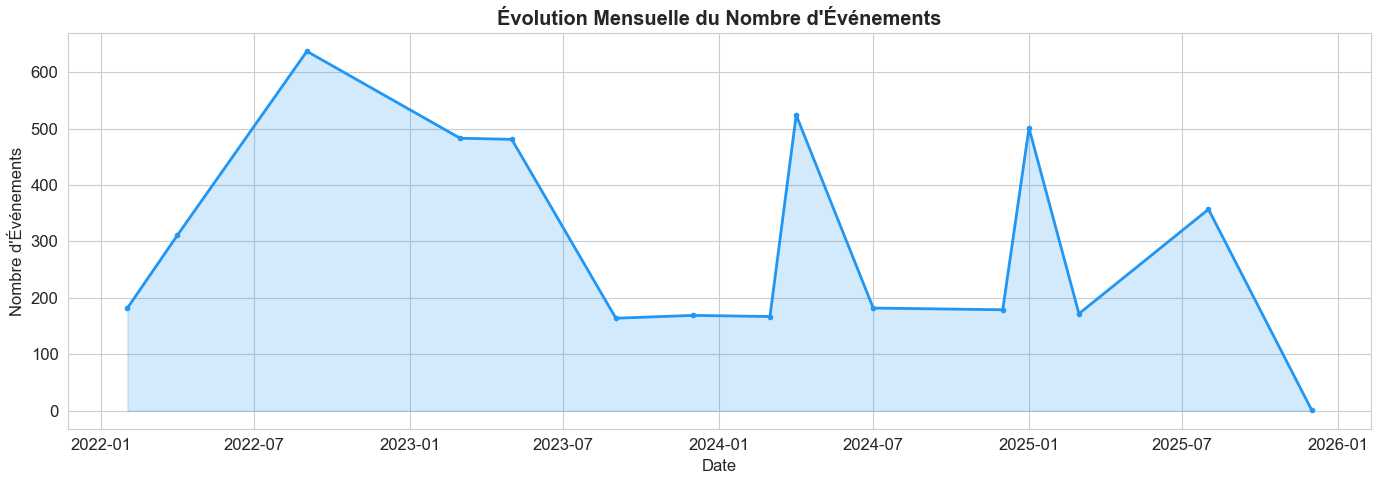

In [ ]:
#Événements par mois
events_by_month = event_clean.groupby(['year', 'month']).size().reset_index(name='count')
events_by_month['date'] = pd.to_datetime(events_by_month[['year', 'month']].assign(day=1))
events_by_month = events_by_month.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(events_by_month['date'], events_by_month['count'],
         color='#2196F3', linewidth=2, marker='o', markersize=3)
plt.fill_between(events_by_month['date'], events_by_month['count'], alpha=0.2, color='#2196F3')
plt.title('Évolution Mensuelle du Nombre d\'Événements', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Nombre d\'Événements')
plt.tight_layout()
plt.savefig('events_timeline.png', bbox_inches='tight', dpi=150)
plt.show()

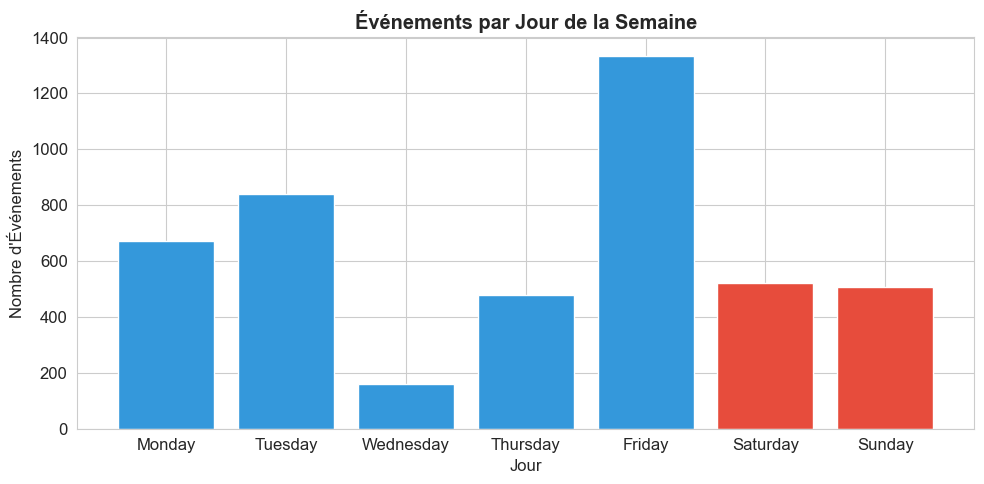

In [ ]:
#Événements par jour de la semaine
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = event_clean['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in weekday_order]
plt.bar(weekday_counts.index, weekday_counts.values, color=colors)
plt.title('Événements par Jour de la Semaine', fontweight='bold')
plt.xlabel('Jour')
plt.ylabel('Nombre d\'Événements')
plt.tight_layout()
plt.savefig('events_weekday.png', bbox_inches='tight', dpi=150)
plt.show()

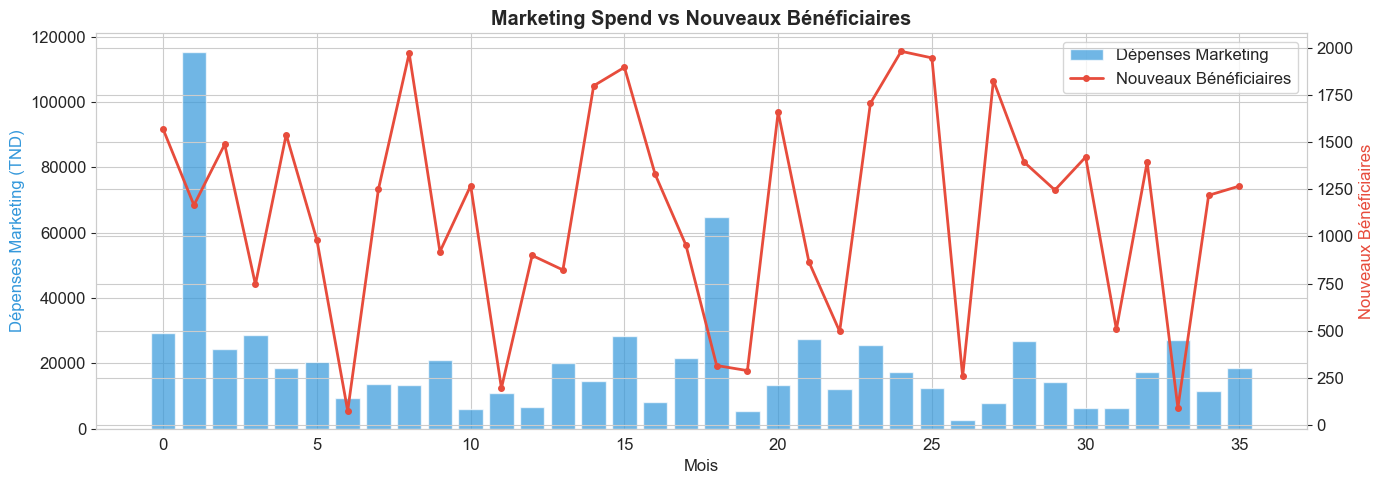

In [ ]:
#Dépenses marketing vs nouveaux bénéficiaires
fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax1.bar(range(len(mkt_clean)), mkt_clean['marketing_spend'],
        color='#3498db', alpha=0.7, label='Dépenses Marketing')
ax2.plot(range(len(mkt_clean)), mkt_clean['new_beneficiaries'],
         color='#e74c3c', linewidth=2, marker='o', markersize=4, label='Nouveaux Bénéficiaires')

ax1.set_xlabel('Mois')
ax1.set_ylabel('Dépenses Marketing (TND)', color='#3498db')
ax2.set_ylabel('Nouveaux Bénéficiaires', color='#e74c3c')
plt.title('Marketing Spend vs Nouveaux Bénéficiaires', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('marketing_vs_beneficiaries.png', bbox_inches='tight', dpi=150)
plt.show()

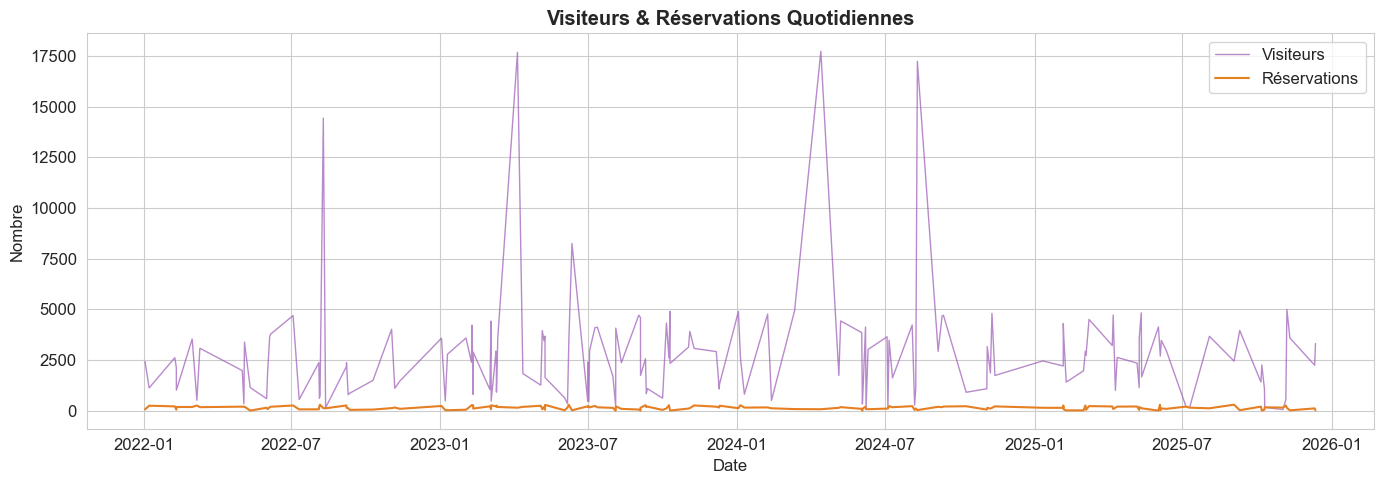

In [ ]:
#Visiteurs vs Réservations (table VISITORS)
plt.figure(figsize=(14, 5))
vis_sorted = vis_clean_dates.sort_values('date')

plt.plot(vis_sorted['date'], vis_sorted['visitors'],
         label='Visiteurs', color='#9b59b6', alpha=0.7, linewidth=1)
plt.plot(vis_sorted['date'], vis_sorted['reservations'],
         label='Réservations', color='#e67e22', linewidth=1.5)
plt.title('Visiteurs & Réservations Quotidiennes', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Nombre')
plt.legend()
plt.tight_layout()
plt.savefig('visitors_reservations.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.4 — Analyse croisée (Cross-Analysis)

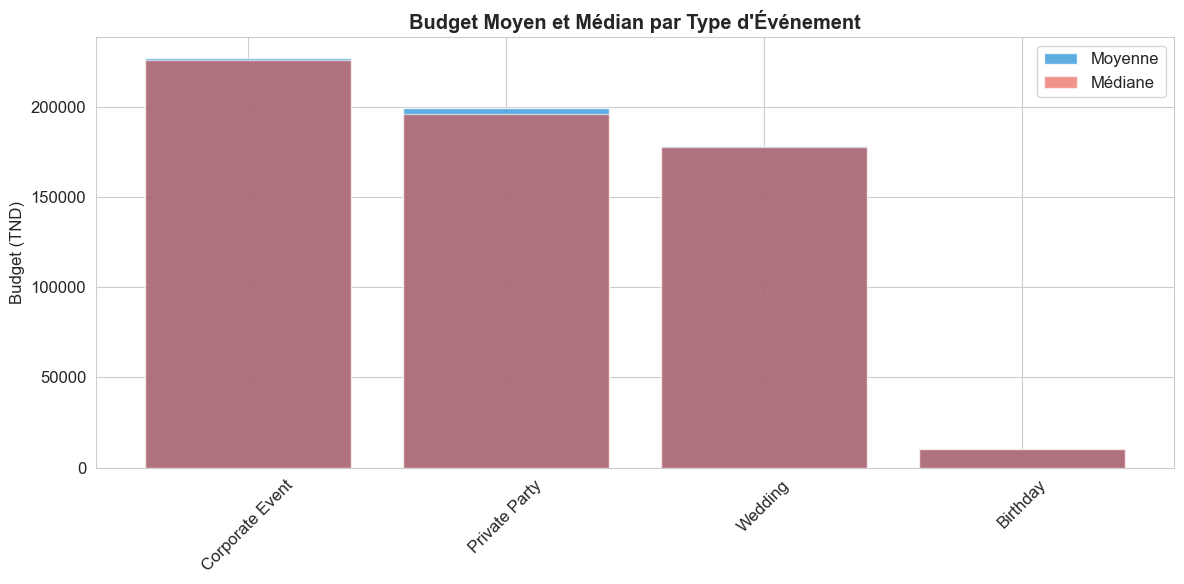

,Moyenne,Médiane,Écart-Type
type,,,
Corporate Event,227041.0,225798.0,126119.0
Private Party,199201.0,195784.0,113672.0
Wedding,178308.0,177842.0,99334.0
Birthday,10558.0,10606.0,5495.0


In [ ]:
#Budget moyen par type d'événement
budget_by_type = event_clean.groupby('type')['budget'].agg(['mean', 'median', 'std']).round(0)
budget_by_type.columns = ['Moyenne', 'Médiane', 'Écart-Type']
budget_by_type = budget_by_type.sort_values('Moyenne', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(budget_by_type))
plt.bar(x, budget_by_type['Moyenne'], color='#3498db', alpha=0.8, label='Moyenne')
plt.bar(x, budget_by_type['Médiane'], color='#e74c3c', alpha=0.6, label='Médiane')
plt.xticks(x, budget_by_type.index, rotation=45)
plt.title('Budget Moyen et Médian par Type d\'Événement', fontweight='bold')
plt.ylabel('Budget (TND)')
plt.legend()
plt.tight_layout()
plt.savefig('budget_by_type.png', bbox_inches='tight', dpi=150)
plt.show()

display(budget_by_type)

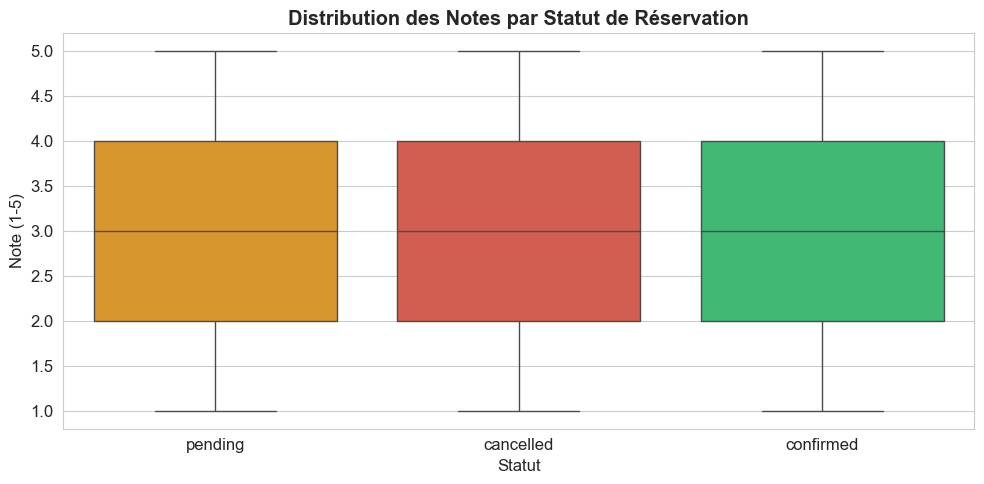

In [ ]:
#Note moyenne par statut de réservation
merged_eval = evl_clean.merge(res_clean_dates[['id_reservation', 'status', 'final_price']],
                               on='id_reservation', how='inner')

plt.figure(figsize=(10, 5))
sns.boxplot(data=merged_eval, x='status', y='rating',
            palette={'confirmed': '#2ecc71', 'pending': '#f39c12', 'cancelled': '#e74c3c'})
plt.title('Distribution des Notes par Statut de Réservation', fontweight='bold')
plt.xlabel('Statut')
plt.ylabel('Note (1-5)')
plt.tight_layout()
plt.savefig('rating_by_status.png', bbox_inches='tight', dpi=150)
plt.show()

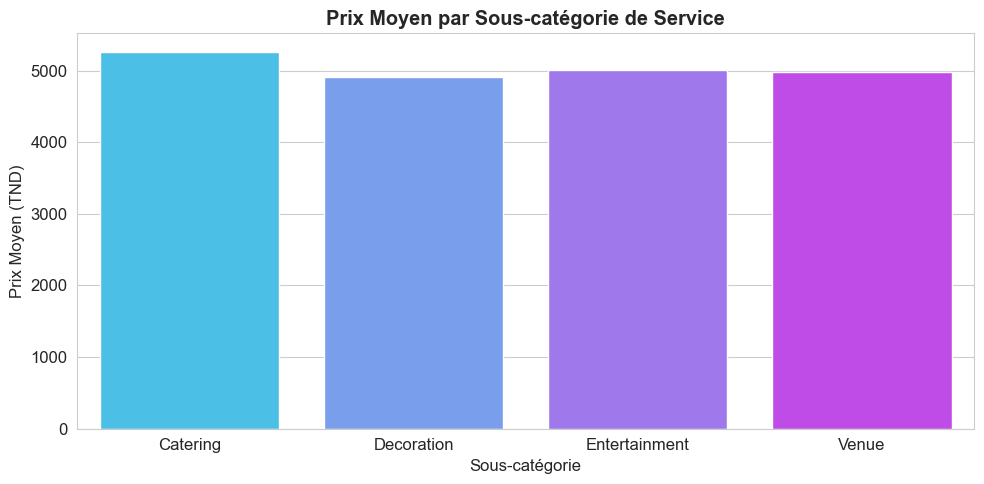

,Sous-catégorie,Prix Moyen,Nb Services
0,Catering,5259.597456,629
1,Decoration,4916.039906,639
2,Entertainment,5007.798013,604
3,Venue,4989.256688,628


In [ ]:
# Prix moyen par sous-catégorie de service
svc_subcat = svc_clean.merge(subcategory[['id_subcategory', 'name']], on='id_subcategory')
price_by_subcat = svc_subcat.groupby('name')['price'].agg(['mean', 'count']).reset_index()
price_by_subcat.columns = ['Sous-catégorie', 'Prix Moyen', 'Nb Services']

plt.figure(figsize=(10, 5))
sns.barplot(data=price_by_subcat, x='Sous-catégorie', y='Prix Moyen', palette='cool')
plt.title('Prix Moyen par Sous-catégorie de Service', fontweight='bold')
plt.ylabel('Prix Moyen (TND)')
plt.tight_layout()
plt.savefig('price_by_subcategory.png', bbox_inches='tight', dpi=150)
plt.show()

display(price_by_subcat)

## 🔗 5. Matrice de Corrélation & Feature Selection

In [ ]:
#Construction de la table analytique principale (Master Table)
# Jointures : EVENT → RESERVATION → EVALUATION
master = event_clean.merge(
    res_clean_dates[['id_reservation', 'id_event', 'id_service', 'status', 'final_price']],
    on='id_event', how='left'
).merge(
    evl_clean[['id_reservation', 'rating']],
    on='id_reservation', how='left'
).merge(
    svc_clean[['id_service', 'price', 'id_provider', 'id_subcategory']],
    on='id_service', how='left'
)

# Encodage des catégories
le_type   = LabelEncoder()
le_status = LabelEncoder()
master['type_enc']   = le_type.fit_transform(master['type'].fillna('Unknown'))
master['status_enc'] = le_status.fit_transform(master['status'].fillna('Unknown'))

print(f'✅ Master table créée : {master.shape}')
display(master.head(3))

✅ Master table créée : (23767, 20)


,id_event,title,event_date,budget,type,id_beneficiary,year,month,weekday,quarter,id_reservation,id_service,status,final_price,rating,price,id_provider,id_subcategory,type_enc,status_enc
0,1730,Common special.,2022-04-01 00:12:37,205052,Corporate Event,3590,2022.0,4.0,Friday,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,21,Simply manager.,2022-04-01 00:22:33,45900,Corporate Event,3699,2022.0,4.0,Friday,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
2,8872,Enjoy ahead collection.,2022-04-01 00:36:12,429833,Corporate Event,1596,2022.0,4.0,Friday,2.0,9666.0,1555.0,confirmed,345.0,NaN,3704.0,214.0,1.0,1,2


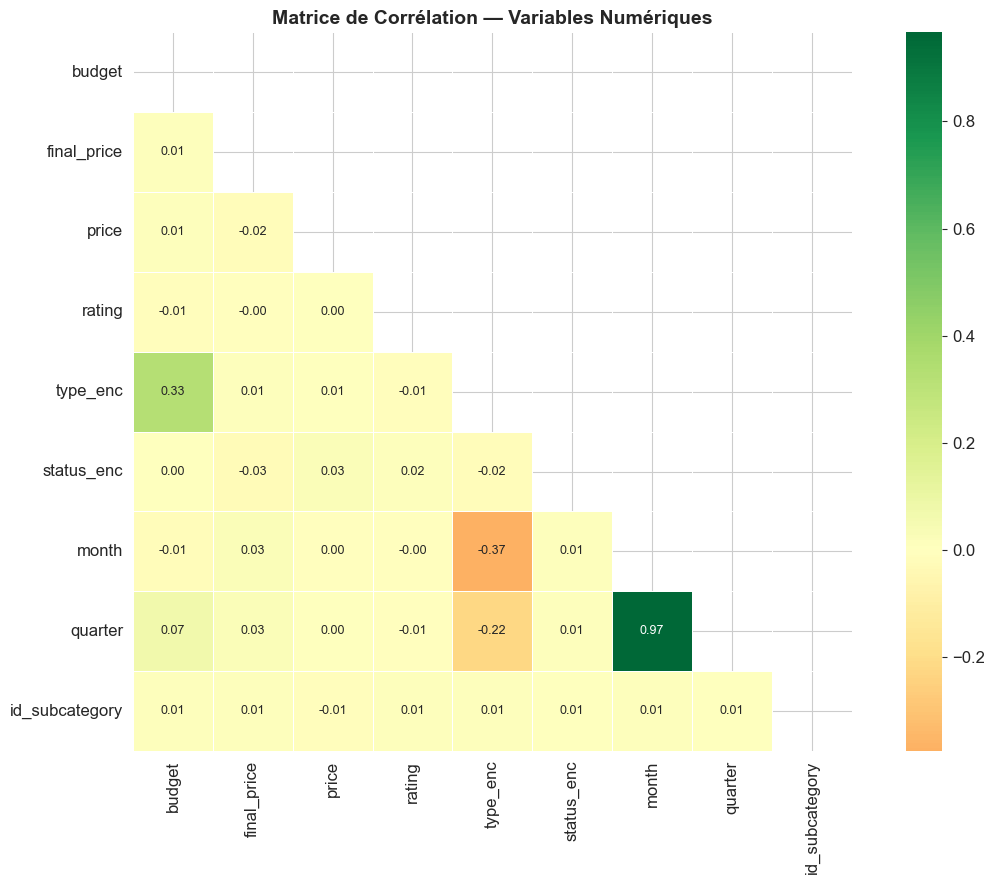

In [ ]:
#  Matrice de corrélation (variables numériques)
corr_cols = ['budget', 'final_price', 'price', 'rating', 'type_enc', 'status_enc',
             'month', 'quarter', 'id_subcategory']

corr_matrix = master[corr_cols].dropna().corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size': 9}, square=True)
plt.title('Matrice de Corrélation — Variables Numériques', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

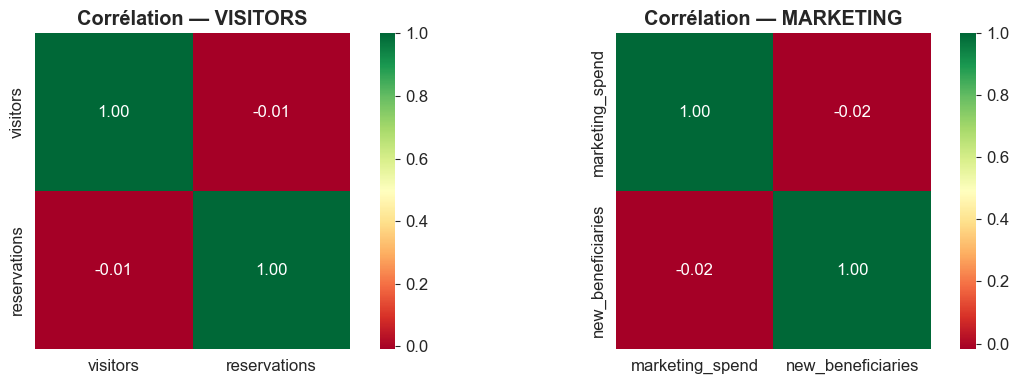

In [ ]:
#Heatmap corrélation VISITORS & MARKETING
vis_corr = vis_clean[['visitors', 'reservations']].corr()
mkt_corr = mkt_clean[['marketing_spend', 'new_beneficiaries']].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(vis_corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], square=True)
axes[0].set_title('Corrélation — VISITORS', fontweight='bold')
sns.heatmap(mkt_corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], square=True)
axes[1].set_title('Corrélation — MARKETING', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_visitors_marketing.png', bbox_inches='tight', dpi=150)
plt.show()

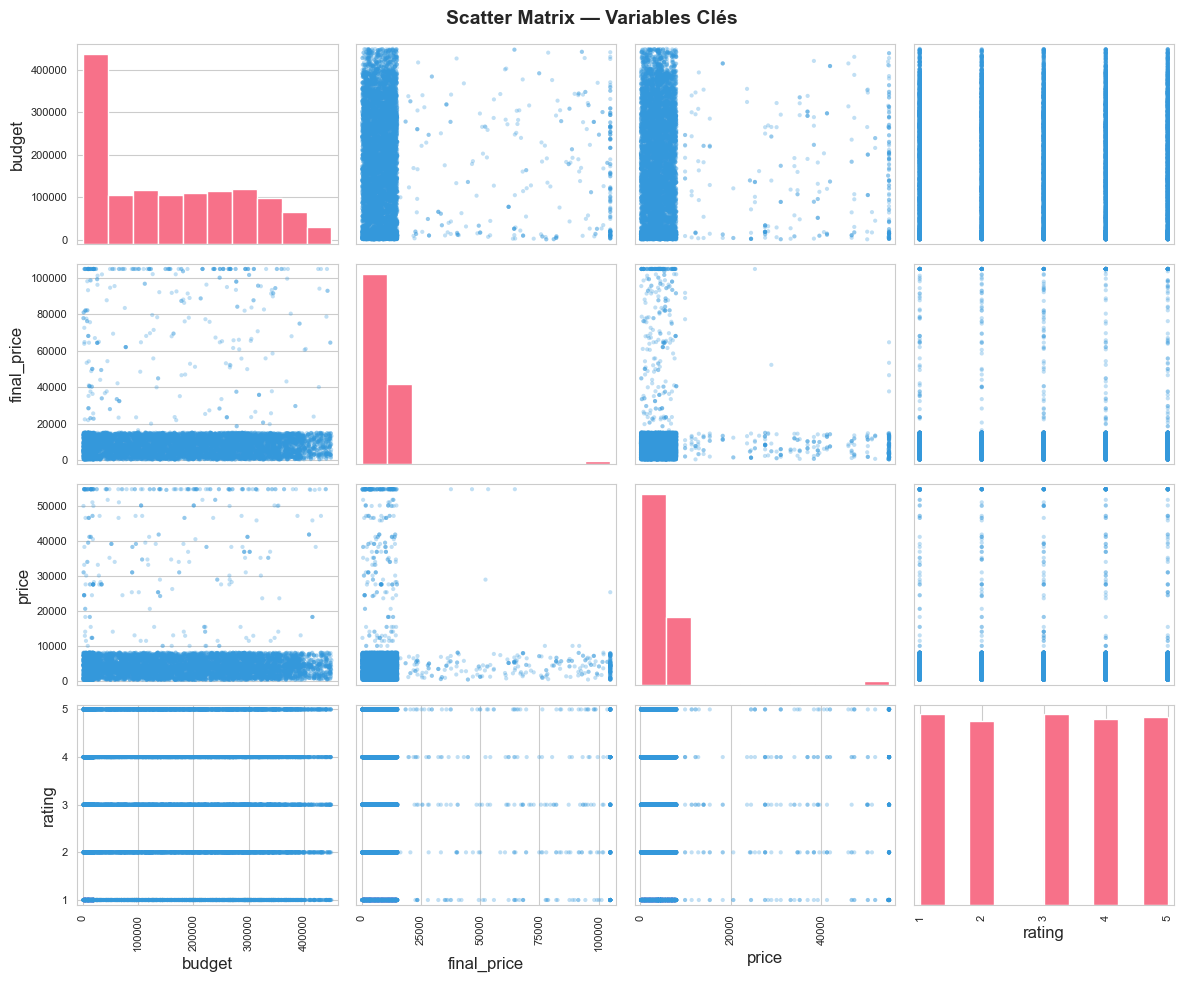

In [ ]:
#  Scatter plots des paires corrélées
from pandas.plotting import scatter_matrix

scatter_cols = ['budget', 'final_price', 'price', 'rating']
scatter_data = master[scatter_cols].dropna()

scatter_matrix(scatter_data, alpha=0.3, figsize=(12, 10), diagonal='hist',
               color='#3498db')
plt.suptitle('Scatter Matrix — Variables Clés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.1 — Feature Selection

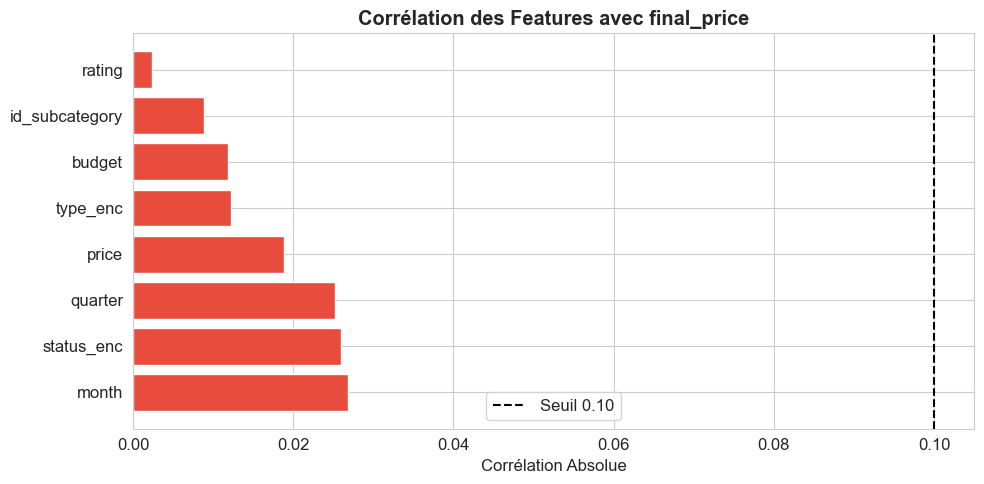


Features sélectionnées (corrélation > 0.10 avec final_price) :


Series([], Name: final_price, dtype: float64)

In [ ]:
#Méthode 1 : Corrélation avec la target (final_price)
target = 'final_price'
features_corr = master[corr_cols].dropna().corr()[target].drop(target).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.1 else '#e74c3c' for v in features_corr.values]
plt.barh(features_corr.index, features_corr.values, color=colors)
plt.axvline(x=0.1, color='black', linestyle='--', linewidth=1.5, label='Seuil 0.10')
plt.title(f'Corrélation des Features avec {target}', fontweight='bold')
plt.xlabel('Corrélation Absolue')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_corr.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nFeatures sélectionnées (corrélation > 0.10 avec {target}) :')
selected = features_corr[features_corr >= 0.10]
display(selected)

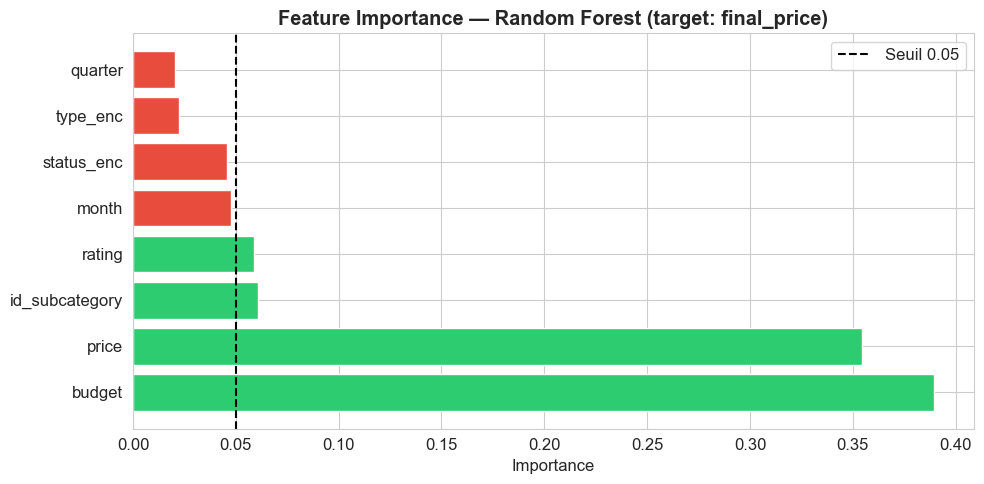


R² sur test set : 0.1479


In [ ]:
# Méthode 2 : Random Forest Feature Importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

feature_cols = ['budget', 'price', 'rating', 'type_enc', 'status_enc', 'month', 'quarter', 'id_subcategory']
ml_data = master[feature_cols + [target]].dropna()

X = ml_data[feature_cols]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' for v in importances.values]
plt.barh(importances.index, importances.values, color=colors)
plt.axvline(x=0.05, color='black', linestyle='--', label='Seuil 0.05')
plt.title('Feature Importance — Random Forest (target: final_price)', fontweight='bold')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nR² sur test set : {rf.score(X_test, y_test):.4f}')

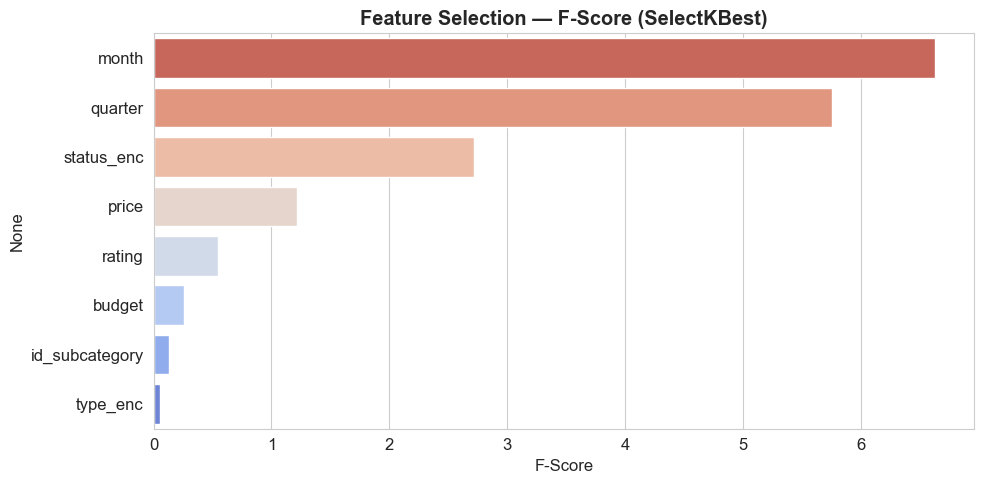


Top 5 features retenues par F-Score :
month         6.630236
quarter       5.759590
status_enc    2.716482
price         1.217143
rating        0.550992


In [ ]:
#Méthode 3 : SelectKBest (F-score)
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

f_scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=f_scores.values, y=f_scores.index, palette='coolwarm_r')
plt.title('Feature Selection — F-Score (SelectKBest)', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('feature_selection_fscore.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTop 5 features retenues par F-Score :')
print(f_scores.head(5).to_string())

In [ ]:
# Résumé : Features sélectionnées
print('━'*60)
print('🎯 RÉCAPITULATIF — FEATURES SÉLECTIONNÉES')
print('━'*60)

# Top 5 par chaque méthode
top_corr = set(features_corr[features_corr >= 0.10].index.tolist())
top_rf   = set(importances[importances >= 0.05].index.tolist())
top_f    = set(f_scores.head(5).index.tolist())

final_features = top_corr & top_rf  # Intersection des deux méthodes principales

print(f'\n  Corrélation (≥0.10)     : {sorted(top_corr)}')
print(f'  Random Forest (≥0.05)   : {sorted(top_rf)}')
print(f'  F-Score (top 5)         : {sorted(top_f)}')
print(f'\n  ✅ Features finales     : {sorted(final_features)}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 RÉCAPITULATIF — FEATURES SÉLECTIONNÉES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Corrélation (≥0.10)     : []
  Random Forest (≥0.05)   : ['budget', 'id_subcategory', 'price', 'rating']
  F-Score (top 5)         : ['month', 'price', 'quarter', 'rating', 'status_enc']

  ✅ Features finales     : []


## 🎨 6. Visualisations Avancées

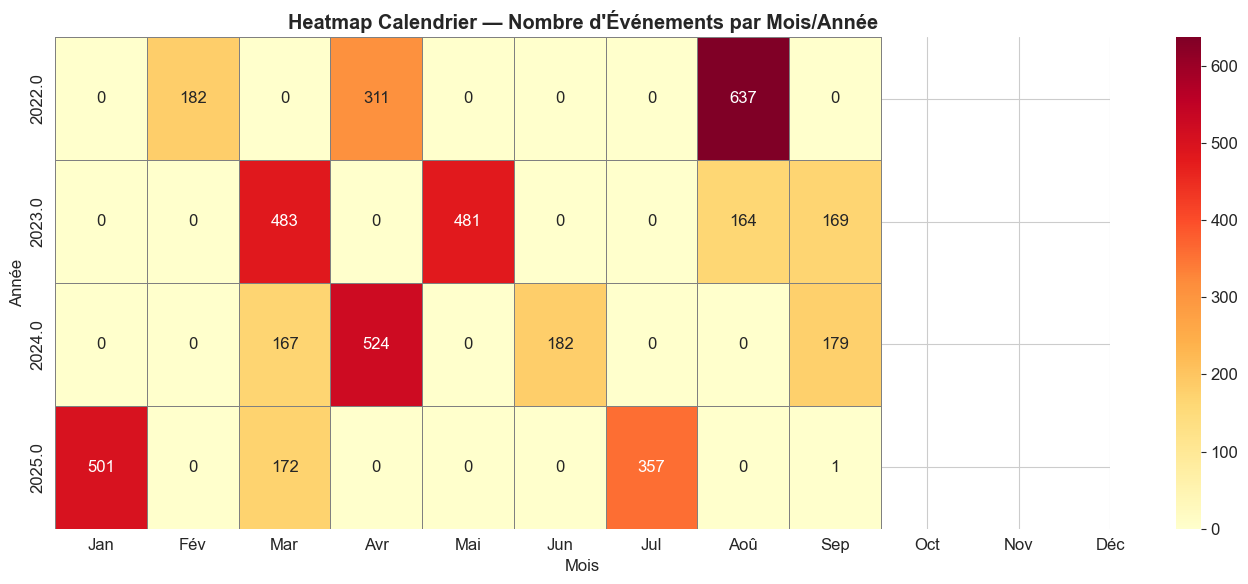

In [ ]:
# Heatmap calendrier : Événements par mois/année
pivot = event_clean.groupby(['year', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='gray',
            xticklabels=['Jan','Fév','Mar','Avr','Mai','Jun',
                         'Jul','Aoû','Sep','Oct','Nov','Déc'])
plt.title('Heatmap Calendrier — Nombre d\'Événements par Mois/Année', fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Année')
plt.tight_layout()
plt.savefig('heatmap_calendar.png', bbox_inches='tight', dpi=150)
plt.show()

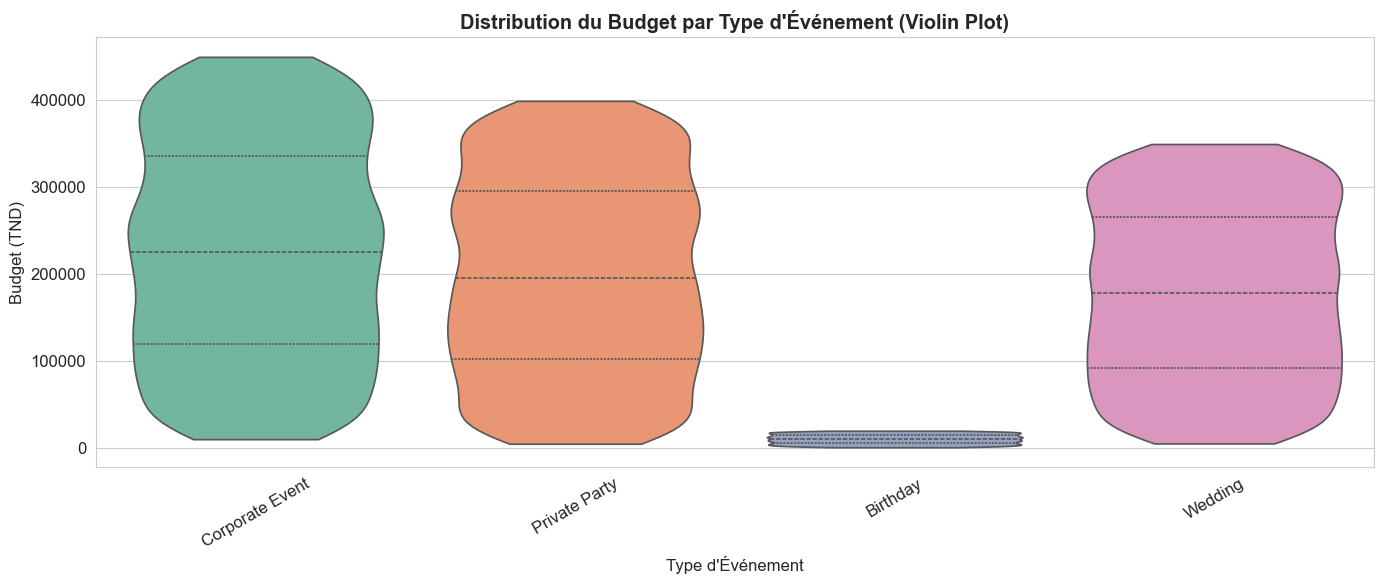

In [ ]:
#Violin plots : Budget par type d'événement
plt.figure(figsize=(14, 6))
sns.violinplot(data=event_clean, x='type', y='budget',
               palette='Set2', inner='quartile', cut=0)
plt.title('Distribution du Budget par Type d\'Événement (Violin Plot)', fontweight='bold')
plt.xlabel('Type d\'Événement')
plt.ylabel('Budget (TND)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('violin_budget.png', bbox_inches='tight', dpi=150)
plt.show()

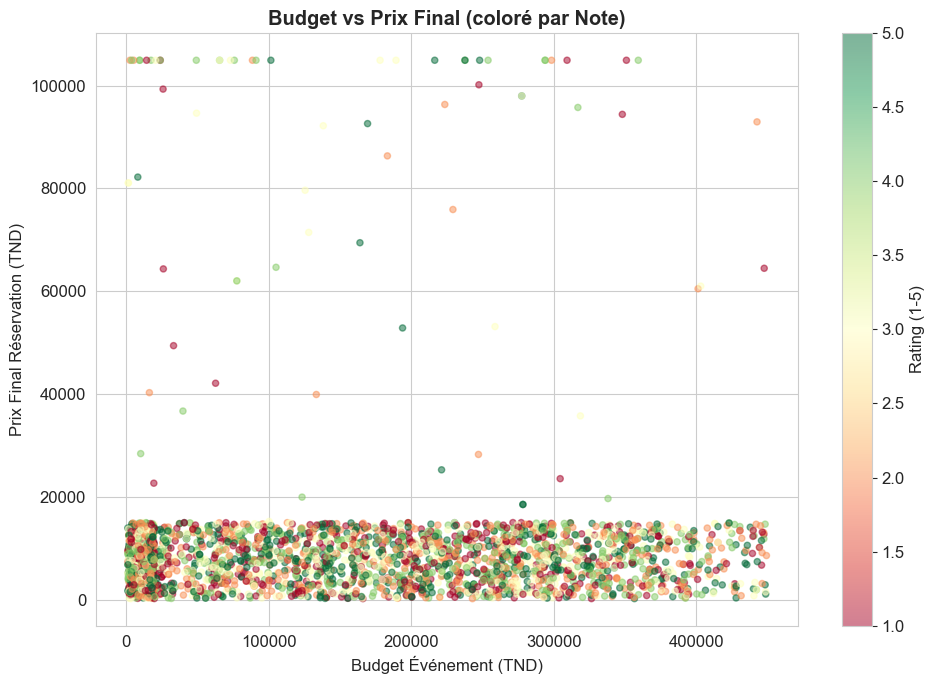

In [ ]:
# Scatter : Budget vs Final Price coloré par Rating
plot_data = master[['budget', 'final_price', 'rating']].dropna().sample(3000, random_state=42)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(plot_data['budget'], plot_data['final_price'],
                      c=plot_data['rating'], cmap='RdYlGn',
                      alpha=0.5, s=20, vmin=1, vmax=5)
plt.colorbar(scatter, label='Rating (1-5)')
plt.title('Budget vs Prix Final (coloré par Note)', fontweight='bold')
plt.xlabel('Budget Événement (TND)')
plt.ylabel('Prix Final Réservation (TND)')
plt.tight_layout()
plt.savefig('scatter_budget_price_rating.png', bbox_inches='tight', dpi=150)
plt.show()

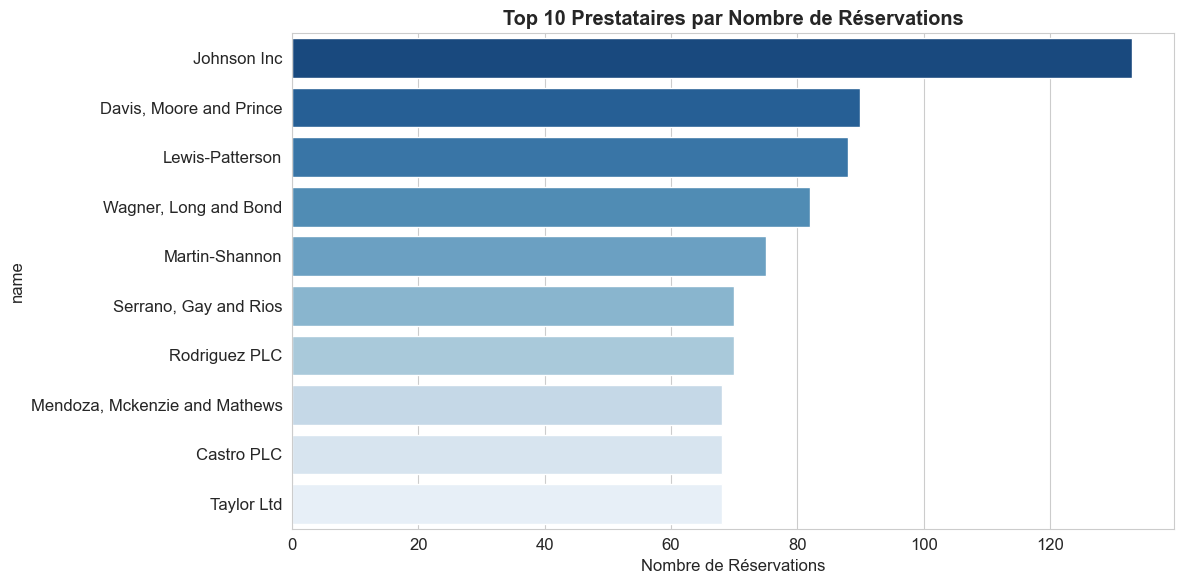

In [ ]:
# Top 10 prestataires par nombre de réservations
top_providers = (
    res_clean_dates
    .merge(svc_clean[['id_service', 'id_provider']], on='id_service')
    .merge(provider[['id_provider', 'name']], on='id_provider')
    .groupby('name')['id_reservation'].count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_providers.values, y=top_providers.index, palette='Blues_r')
plt.title('Top 10 Prestataires par Nombre de Réservations', fontweight='bold')
plt.xlabel('Nombre de Réservations')
plt.tight_layout()
plt.savefig('top_providers.png', bbox_inches='tight', dpi=150)
plt.show()

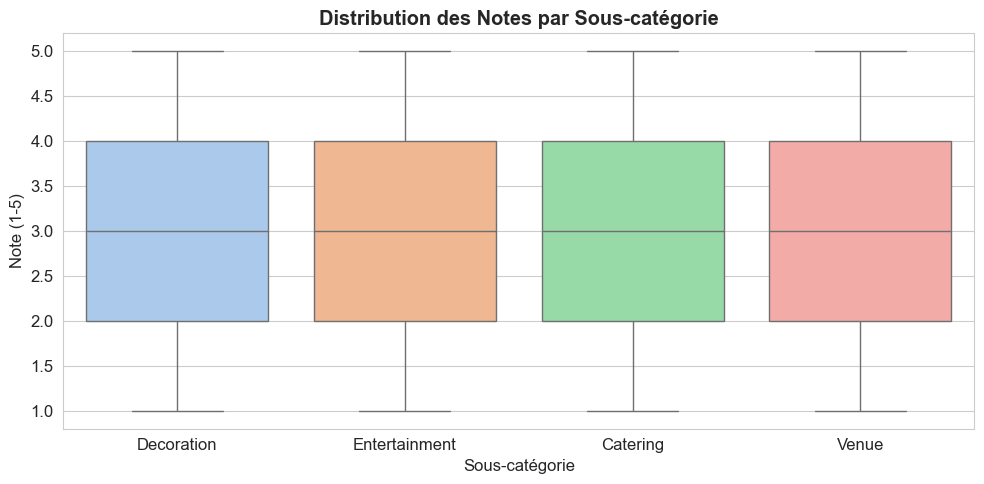

In [ ]:
# Distribution des ratings par sous-catégorie
rating_subcat = (
    merged_eval
    .merge(svc_clean[['id_service', 'id_subcategory']], left_on='id_reservation', right_on='id_service', how='left')
    .merge(subcategory[['id_subcategory', 'name']], on='id_subcategory', how='left')
)
# Utilisation directe de master pour la jointure correcte
rating_sub_data = master[['rating', 'id_subcategory']].dropna()
rating_sub_data = rating_sub_data.merge(subcategory[['id_subcategory', 'name']], on='id_subcategory')

plt.figure(figsize=(10, 5))
sns.boxplot(data=rating_sub_data, x='name', y='rating', palette='pastel')
plt.title('Distribution des Notes par Sous-catégorie', fontweight='bold')
plt.xlabel('Sous-catégorie')
plt.ylabel('Note (1-5)')
plt.tight_layout()
plt.savefig('rating_by_subcategory.png', bbox_inches='tight', dpi=150)
plt.show()

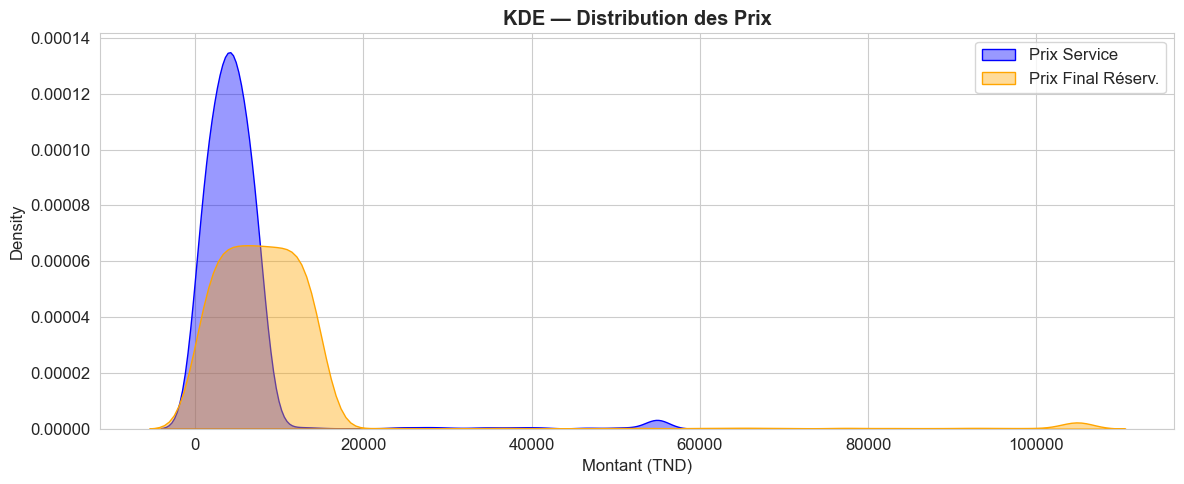

In [ ]:
# KDE prix service vs prix final réservation
plt.figure(figsize=(12, 5))
sns.kdeplot(svc_clean['price'].dropna(),      label='Prix Service',      fill=True, alpha=0.4, color='blue')
sns.kdeplot(res_clean['final_price'].dropna(), label='Prix Final Réserv.', fill=True, alpha=0.4, color='orange')
plt.title('KDE — Distribution des Prix', fontweight='bold')
plt.xlabel('Montant (TND)')
plt.legend()
plt.tight_layout()
plt.show()

## 🎨 7.Valeurs manquantes → Imputer  (tu conserves toutes les données)
Outliers logiquement impossibles (rating > 5) → Supprimer

Outliers extrêmes mais possibles → Winsoriser

In [ ]:
# ════════════════════════════════════════════════════
# NETTOYAGE FINAL — EVENTZELLA
# ════════════════════════════════════════════════════

print("AVANT nettoyage :")
print(f"  BENEFICIARY : {beneficiary.shape}")
print(f"  SERVICE     : {service.shape}")
print(f"  EVALUATION  : {evaluation.shape}")
print(f"  RESERVATION : {reservation.shape}")

AVANT nettoyage :
  BENEFICIARY : (5000, 5)
  SERVICE     : (2500, 6)
  EVALUATION  : (12000, 4)
  RESERVATION : (18000, 6)


In [ ]:
# ── VALEURS MANQUANTES ───────────────────────────────
ben  = beneficiary.copy()
prov = provider.copy()
svc  = service.copy()
evl  = evaluation.copy()

# BENEFICIARY — texte → remplacer
ben['last_name'].fillna('Unknown', inplace=True)
ben['email'].fillna('no_email@unknown.com', inplace=True)

# PROVIDER — texte → remplacer
prov['email'].fillna('no_email@provider.com', inplace=True)

# SERVICE — price numérique → médiane par groupe
svc['price'] = svc.groupby('id_subcategory')['price'].transform(
    lambda x: x.fillna(x.median())
)
svc['price'].fillna(svc['price'].median(), inplace=True)
svc['title'].fillna('No Title', inplace=True)

# EVALUATION — texte → remplacer
evl['comment'].fillna('No Comment', inplace=True)

print("✅ Valeurs manquantes traitées")
for name, df in [('BENEFICIARY',ben),('PROVIDER',prov),('SERVICE',svc),('EVALUATION',evl)]:
    print(f"  {name:15s} → {df.isnull().sum().sum()} NaN restants")

✅ Valeurs manquantes traitées
  BENEFICIARY     → 0 NaN restants
  PROVIDER        → 0 NaN restants
  SERVICE         → 0 NaN restants
  EVALUATION      → 0 NaN restants


In [ ]:
# ── OUTLIERS ─────────────────────────────────────────

# 1. EVALUATION.rating > 5 → SUPPRIMER (erreur logique)
avant = len(evl)
evl = evl[evl['rating'] <= 5]
print(f"EVALUATION : {avant - len(evl)} lignes supprimées (rating > 5)")

# 2. Winsorisation pour les autres (valeurs extrêmes mais réelles)
svc_clean = svc.copy()
res_clean = reservation.copy()
vis_clean = visitors.copy()
mkt_clean = marketing.copy()

svc_clean['price']           = svc_clean['price'].clip(upper=svc_clean['price'].quantile(0.99))
res_clean['final_price']     = res_clean['final_price'].clip(upper=res_clean['final_price'].quantile(0.99))
vis_clean['visitors']        = vis_clean['visitors'].clip(upper=vis_clean['visitors'].quantile(0.99))
mkt_clean['marketing_spend'] = mkt_clean['marketing_spend'].clip(upper=mkt_clean['marketing_spend'].quantile(0.99))

event_clean = event.copy()
event_clean['event_date'] = pd.to_datetime(event_clean['event_date'], errors='coerce')
event_clean['year']    = event_clean['event_date'].dt.year
event_clean['month']   = event_clean['event_date'].dt.month
event_clean['quarter'] = event_clean['event_date'].dt.quarter
event_clean['weekday'] = event_clean['event_date'].dt.day_name()

print("✅ Outliers traités (winsorisation + suppression rating > 5)")

EVALUATION : 312 lignes supprimées (rating > 5)
✅ Outliers traités (winsorisation + suppression rating > 5)


In [ ]:
# ── CONSTRUCTION MASTER TABLE ────────────────────────
master = event_clean.merge(
    res_clean[['id_reservation','id_event','id_service','status','final_price']],
    on='id_event', how='left'
).merge(
    evl[['id_reservation','rating']], on='id_reservation', how='left'
).merge(
    svc_clean[['id_service','price','id_provider','id_subcategory']], on='id_service', how='left'
)

le = LabelEncoder()
master['type_enc']   = le.fit_transform(master['type'].fillna('Unknown'))
master['status_enc'] = le.fit_transform(master['status'].fillna('Unknown'))

print(f"✅ Master table : {master.shape}")

✅ Master table : (23767, 20)


In [ ]:
# ── SUPPRESSION DES NaN RESTANTS pour ML/Corrélation ─
corr_cols     = ['budget','final_price','price','rating',
                 'type_enc','status_enc','month','quarter','id_subcategory']
feature_cols  = ['budget','price','rating','type_enc',
                 'status_enc','month','quarter','id_subcategory']
target        = 'final_price'

master_ml = master[corr_cols].dropna().reset_index(drop=True)

print(f"Master table complète  : {master.shape[0]:,} lignes")
print(f"Master table pour ML   : {master_ml.shape[0]:,} lignes")
print(f"Lignes retirées (NaN)  : {master.shape[0] - master_ml.shape[0]:,} lignes")
print(f"% conservé             : {master_ml.shape[0]/master.shape[0]*100:.1f}%")

Master table complète  : 23,767 lignes
Master table pour ML   : 4,471 lignes
Lignes retirées (NaN)  : 19,296 lignes
% conservé             : 18.8%


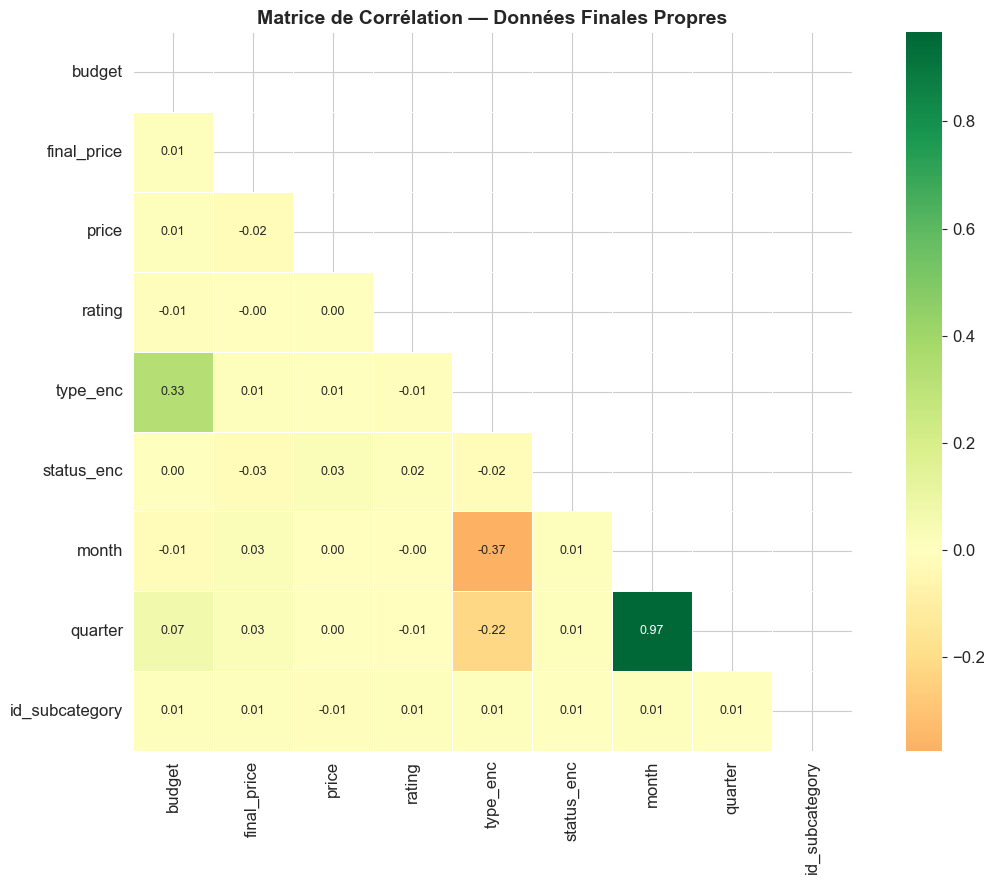

In [ ]:
# ── MATRICE DE CORRÉLATION FINALE ────────────────────
corr_matrix = master_ml.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size':9}, square=True)
plt.title('Matrice de Corrélation — Données Finales Propres', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

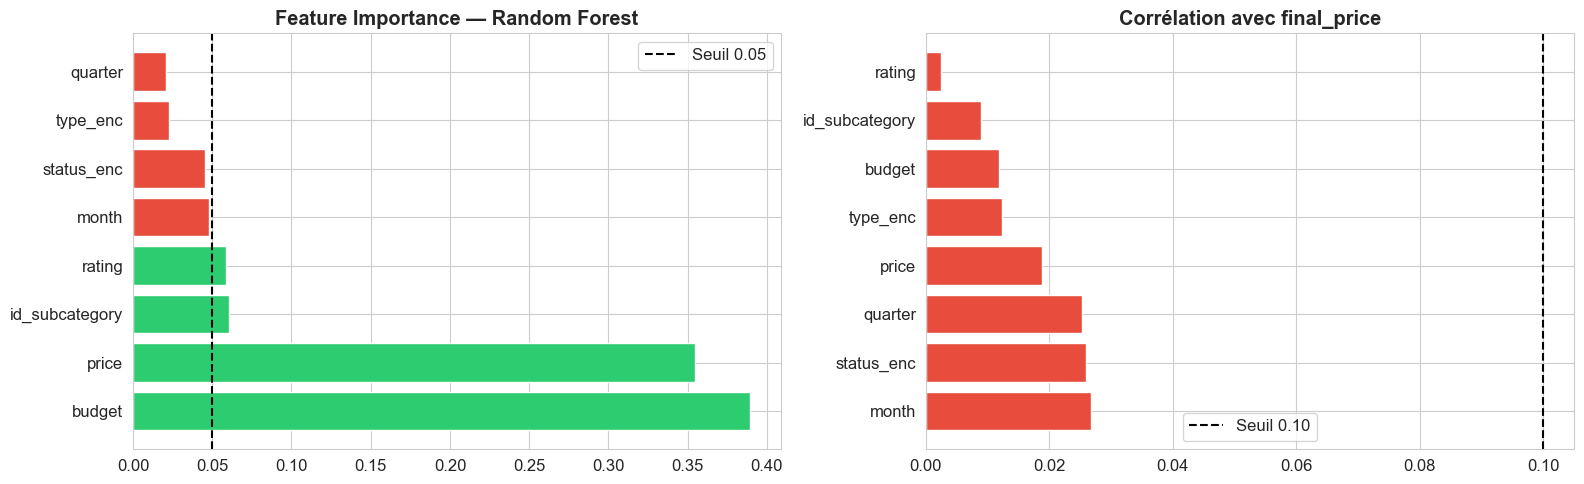


R² Random Forest : 0.1479

Features retenues (RF >= 0.05) : ['budget', 'price', 'id_subcategory', 'rating']
Features retenues (Corr >= 0.10): []


In [ ]:
# ── FEATURE SELECTION FINALE ─────────────────────────
X = master_ml[feature_cols]
y = master_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 : RF Importance
colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' for v in importances.values]
axes[0].barh(importances.index, importances.values, color=colors)
axes[0].axvline(x=0.05, color='black', linestyle='--', label='Seuil 0.05')
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].legend()

# Plot 2 : Corrélation avec target
feat_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
colors2 = ['#2ecc71' if v >= 0.1 else '#e74c3c' for v in feat_corr.values]
axes[1].barh(feat_corr.index, feat_corr.values, color=colors2)
axes[1].axvline(x=0.1, color='black', linestyle='--', label='Seuil 0.10')
axes[1].set_title(f'Corrélation avec {target}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nR² Random Forest : {rf.score(X_test, y_test):.4f}')
print(f'\nFeatures retenues (RF >= 0.05) : {list(importances[importances >= 0.05].index)}')
print(f'Features retenues (Corr >= 0.10): {list(feat_corr[feat_corr >= 0.10].index)}')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, silhouette_score)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, RandomForestClassifier,
                               GradientBoostingClassifier, ExtraTreesClassifier,
                               VotingClassifier, AdaBoostClassifier,
                               IsolationForest)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier, LocalOutlierFactor
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print("✅ Imports OK")

✅ Imports OK


In [ ]:
# ── Reprendre master_ml déjà créé ────────────────────
# Si tu recommences depuis zéro, relance d'abord le code de nettoyage

corr_cols    = ['budget','final_price','price','rating',
                'type_enc','status_enc','month','quarter','id_subcategory']
feature_cols = ['budget','price','rating','type_enc',
                'status_enc','month','quarter','id_subcategory']
target_reg   = 'final_price'
target_cls   = 'status_enc'

master_ml = master[corr_cols].dropna().reset_index(drop=True)

X_reg = master_ml[feature_cols]
y_reg = master_ml[target_reg]

X_cls = master_ml[feature_cols]
y_cls = master_ml[target_cls]

scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
X_cls_scaled = scaler.fit_transform(X_cls)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42)

print(f"✅ Données prêtes")
print(f"   Régression  — Train: {X_train_r.shape}  Test: {X_test_r.shape}")
print(f"   Classification — Train: {X_train_c.shape}  Test: {X_test_c.shape}")

✅ Données prêtes
   Régression  — Train: (3576, 8)  Test: (895, 8)
   Classification — Train: (3576, 8)  Test: (895, 8)


## 🤖 8. Recommendation Multi-Bots (2 cas metier)

Objectifs:
- Bot 1: Multi-Service Bundle Recommendation
  - Systeme: Association Rules (Apriori) pour recommander des combinaisons de services
- Bot 2: Recommend Services (Upselling)
  - Systeme: Collaborative Filtering (item-item) avec contrainte budget

Exigences couvertes:
- Metriques: support, confidence, lift (Apriori) + precision@K, recall@K, hit rate@K (CF)
- Interpretation: top bundles, regles fortes, services similaires, logique de recommandation
- Visualisations: bundles frequents, scatter support/lift, heatmap co-occurrence/similarite
- Export des artefacts recommender en fichiers pkl

In [15]:
# =========================
# Imports + Helpers (Recommendation Bots)
# =========================

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from collections import defaultdict
import pickle

# Try mlxtend, otherwise fallback to custom Apriori-like implementation
HAS_MLXTEND = True
try:
    from mlxtend.frequent_patterns import apriori as mlxtend_apriori, association_rules as mlxtend_association_rules
except Exception:
    HAS_MLXTEND = False
    mlxtend_apriori = None
    mlxtend_association_rules = None

RANDOM_STATE_REC = 42


def safe_title_from_service(service_df):
    if 'title' in service_df.columns:
        return service_df['title'].fillna('No Title')
    if 'name' in service_df.columns:
        return service_df['name'].fillna('No Name')
    return service_df['id_service'].astype(str)


def precision_recall_hit_at_k(test_items, rec_items, k=5):
    rec_k = rec_items[:k]
    if len(test_items) == 0:
        return np.nan, np.nan, np.nan
    hits = len(set(test_items) & set(rec_k))
    precision = hits / max(1, len(rec_k))
    recall = hits / len(set(test_items))
    hit = 1.0 if hits > 0 else 0.0
    return precision, recall, hit


def cosine_similarity_matrix(X):
    # X: matrix users x items
    X = np.asarray(X, dtype=float)
    item_mat = X.T  # items x users
    norms = np.linalg.norm(item_mat, axis=1, keepdims=True) + 1e-12
    item_mat_norm = item_mat / norms
    sim = item_mat_norm @ item_mat_norm.T
    sim = np.clip(sim, -1.0, 1.0)
    return sim


def cosine_similarity_np(X):
    # Alias used by Bot 2 cell
    return cosine_similarity_matrix(X)


def run_apriori_rules(basket, min_support=0.01, min_confidence=0.1, min_lift=1.0, max_len=3):
    basket_bin = (basket > 0).astype(int)

    if HAS_MLXTEND:
        freq_items = mlxtend_apriori(basket_bin, min_support=min_support, use_colnames=True, max_len=max_len)
        if freq_items.empty:
            empty_rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
            return freq_items, empty_rules
        rules = mlxtend_association_rules(freq_items, metric='lift', min_threshold=min_lift)
        if rules.empty:
            rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
        else:
            rules = rules[rules['confidence'] >= min_confidence].copy()
        return freq_items, rules

    # Fallback: simple Apriori-like counting for lengths 1..max_len
    supports = {}
    cols = list(basket_bin.columns)

    # Precompute single-item support
    for c in cols:
        supp = basket_bin[c].mean()
        if supp >= min_support:
            supports[frozenset([c])] = supp

    # Generate itemsets of size >=2
    for L in range(2, max_len + 1):
        for comb in combinations(cols, L):
            fs = frozenset(comb)
            mask = basket_bin[list(comb)].all(axis=1)
            supp = mask.mean()
            if supp >= min_support:
                supports[fs] = supp

    # Frequent itemsets dataframe
    freq_items = pd.DataFrame({
        'itemsets': list(supports.keys()),
        'support': list(supports.values()),
    })

    # Rules dataframe
    rules_rows = []
    for itemset, supp_xy in supports.items():
        if len(itemset) < 2:
            continue
        itemset_list = list(itemset)
        for r in range(1, len(itemset_list)):
            for ant in combinations(itemset_list, r):
                ant = frozenset(ant)
                cons = frozenset(itemset - ant)
                supp_x = supports.get(ant, 0)
                supp_y = supports.get(cons, 0)
                if supp_x <= 0 or supp_y <= 0:
                    continue
                conf = supp_xy / supp_x
                lift = conf / supp_y
                if conf >= min_confidence and lift >= min_lift:
                    rules_rows.append({
                        'antecedents': ant,
                        'consequents': cons,
                        'support': supp_xy,
                        'confidence': conf,
                        'lift': lift,
                    })

    rules = pd.DataFrame(rules_rows)
    if rules.empty:
        rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
    return freq_items, rules


print(f'✅ Helpers recommendation prets (mlxtend={HAS_MLXTEND})')

✅ Helpers recommendation prets (mlxtend=True)


In [17]:
# ==========================================================
# BOT 1 - Multi-Service Bundle Recommendation (Apriori)
# ==========================================================

svc_b1 = service.copy()
svc_b1['service_label'] = safe_title_from_service(svc_b1)

res_b1 = reservation.copy()
if 'id_reservation' not in res_b1.columns or 'id_service' not in res_b1.columns:
    raise ValueError("RESERVATION doit contenir id_reservation et id_service pour Apriori.")

basket_df = res_b1[['id_reservation', 'id_service']].dropna().copy()
basket_df = basket_df.drop_duplicates()

# Basket matrix (without pandas crosstab/pivot paths)
res_ids = pd.Index(pd.unique(basket_df['id_reservation']))
svc_ids = pd.Index(pd.unique(basket_df['id_service']))
res_to_i = {rid: i for i, rid in enumerate(res_ids)}
svc_to_j = {sid: j for j, sid in enumerate(svc_ids)}
mat = np.zeros((len(res_ids), len(svc_ids)), dtype=np.int8)

for rid, sid in basket_df[['id_reservation', 'id_service']].itertuples(index=False, name=None):
    mat[res_to_i[rid], svc_to_j[sid]] = 1

basket = pd.DataFrame(mat, index=res_ids, columns=svc_ids)

# Frequent itemsets + rules (mlxtend or fallback)
freq_items, rules = run_apriori_rules(
    basket=basket,
    min_support=0.01,
    min_confidence=0.10,
    min_lift=1.0,
    max_len=3,
)

if not rules.empty:
    rules = rules.sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)

# Mapping service ids -> labels for interpretation
svc_map = svc_b1.set_index('id_service')['service_label'].to_dict()

def decode_fset(fset):
    return [svc_map.get(x, str(x)) for x in list(fset)]

if not rules.empty:
    rules['antecedents_labels'] = rules['antecedents'].apply(decode_fset)
    rules['consequents_labels'] = rules['consequents'].apply(decode_fset)

print('📊 Bot 1 - Apriori summary')
print(f'- Transactions: {basket.shape[0]}')
print(f'- Services: {basket.shape[1]}')
print(f'- Frequent itemsets: {len(freq_items)}')
print(f'- Rules: {len(rules)}')

if not rules.empty:
    display(rules[['antecedents_labels', 'consequents_labels', 'support', 'confidence', 'lift']].head(20))
else:
    print('⚠️ Aucune regle trouvee. Essaie de diminuer min_support.')

# Visualization 1: top itemsets by support
if not freq_items.empty:
    try:
        top_itemsets = freq_items.sort_values('support', ascending=False).head(15).copy()
        top_itemsets['itemset_size'] = top_itemsets['itemsets'].apply(len)

        plt.figure(figsize=(10, 5))
        plt.bar(range(len(top_itemsets)), top_itemsets['support'])
        plt.title('Bot 1 - Top Frequent Itemsets (Support)')
        plt.xlabel('Top itemsets')
        plt.ylabel('Support')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'⚠️ Plot Bot1-1 ignore ({type(e).__name__})')

# Visualization 2: support vs lift
if not rules.empty:
    try:
        plt.figure(figsize=(7, 5))
        plt.scatter(rules['support'], rules['lift'], alpha=0.6)
        plt.title('Bot 1 - Association Rules (Support vs Lift)')
        plt.xlabel('Support')
        plt.ylabel('Lift')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'⚠️ Plot Bot1-2 ignore ({type(e).__name__})')

# Visualization 3: service co-occurrence heatmap (top services)
svc_counts = basket.sum(axis=0).sort_values(ascending=False)
top_services = svc_counts.head(12).index.tolist()
if len(top_services) >= 2:
    try:
        top_basket = basket[top_services]
        cooc = top_basket.T.dot(top_basket)
        top_labels = [svc_map.get(s, str(s)) for s in top_services]

        plt.figure(figsize=(10, 8))
        sns.heatmap(cooc, cmap='Blues', xticklabels=top_labels, yticklabels=top_labels)
        plt.title('Bot 1 - Service Co-occurrence Heatmap (Top Services)')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'⚠️ Plot Bot1-3 ignore ({type(e).__name__})')

# Recommendation helper from selected services
def recommend_bundle_apriori(selected_services, rules_df, top_n=5):
    if rules_df.empty:
        return []
    selected_set = set(selected_services)
    candidates = []

    for _, r in rules_df.iterrows():
        ant = set(r['antecedents'])
        cons = set(r['consequents'])
        if ant.issubset(selected_set) and len(cons - selected_set) > 0:
            candidates.append({
                'recommend': list(cons - selected_set),
                'confidence': r['confidence'],
                'lift': r['lift'],
                'support': r['support'],
            })

    if not candidates:
        return []

    cdf = pd.DataFrame(candidates).sort_values(['lift', 'confidence', 'support'], ascending=False)
    out = []
    for _, row in cdf.head(top_n).iterrows():
        labels = [svc_map.get(s, str(s)) for s in row['recommend']]
        out.append({
            'services': labels,
            'confidence': float(row['confidence']),
            'lift': float(row['lift']),
            'support': float(row['support']),
        })
    return out

# Example usage
example_services = basket.columns[:2].tolist() if basket.shape[1] >= 2 else basket.columns[:1].tolist()
if len(example_services) > 0:
    example_rec = recommend_bundle_apriori(example_services, rules, top_n=3)
    print('Exemple recommandations bundle (Bot 1):')
    print(example_rec)

# Bot 1 summary table
bot1_summary = pd.DataFrame([{
    'model': 'Association Rules (Apriori)',
    'n_transactions': basket.shape[0],
    'n_services': basket.shape[1],
    'n_itemsets': len(freq_items),
    'n_rules': len(rules),
    'avg_lift': float(rules['lift'].mean()) if not rules.empty else np.nan,
    'avg_confidence': float(rules['confidence'].mean()) if not rules.empty else np.nan,
}])
display(bot1_summary)

📊 Bot 1 - Apriori summary
- Transactions: 18000
- Services: 2498
- Frequent itemsets: 0
- Rules: 0
⚠️ Aucune regle trouvee. Essaie de diminuer min_support.
⚠️ Plot Bot1-3 ignore (ImportError)
Exemple recommandations bundle (Bot 1):
[]


,model,n_transactions,n_services,n_itemsets,n_rules,avg_lift,avg_confidence
0,Association Rules (Apriori),18000,2498,0,0,NaN,NaN


In [21]:
# ==========================================================
# BOT 2 - Upsell Recommendation (Collaborative Filtering)
# ==========================================================

res_b2 = reservation.copy()
svc_b2 = service.copy()

# Detect user column robustly on RESERVATION
user_col = None
user_candidates = ['id_user', 'id_beneficiary', 'id_beneficiaire', 'beneficiary_id', 'id_client', 'id_customer']
for c in user_candidates:
    if c in res_b2.columns:
        user_col = c
        break
if user_col is None:
    for c in res_b2.columns:
        lc = str(c).lower()
        if 'benef' in lc or ('user' in lc and lc.startswith('id_')):
            user_col = c
            break

# If RESERVATION has no user id, try derive from EVENT join
if user_col is None and 'id_event' in res_b2.columns and 'event' in globals():
    evt_b2 = event.copy()
    evt_user_col = None
    for c in user_candidates:
        if c in evt_b2.columns:
            evt_user_col = c
            break
    if evt_user_col is None:
        for c in evt_b2.columns:
            lc = str(c).lower()
            if 'benef' in lc or ('user' in lc and lc.startswith('id_')):
                evt_user_col = c
                break

    if evt_user_col is not None and 'id_event' in evt_b2.columns:
        inter_tmp = res_b2[['id_event', 'id_service']].dropna().copy()
        inter_tmp = inter_tmp.merge(
            evt_b2[['id_event', evt_user_col]].drop_duplicates(),
            on='id_event', how='left'
        )
        inter_tmp = inter_tmp.rename(columns={evt_user_col: 'derived_user_id'})
        interactions = inter_tmp[['derived_user_id', 'id_service']].dropna().copy()
        interactions = interactions.rename(columns={'derived_user_id': 'user_id'})
        user_col = 'user_id'
    else:
        interactions = pd.DataFrame()
else:
    interactions = pd.DataFrame()

# Last fallback: use id_event as pseudo-user if still unresolved
if user_col is None:
    if 'id_event' not in res_b2.columns or 'id_service' not in res_b2.columns:
        raise ValueError(
            f"Impossible de construire les interactions. Colonnes RESERVATION: {list(res_b2.columns)}"
        )
    interactions = res_b2[['id_event', 'id_service']].dropna().copy().rename(columns={'id_event': 'user_id'})
    user_col = 'user_id'
elif interactions.empty:
    if 'id_service' not in res_b2.columns:
        raise ValueError(
            f"RESERVATION doit contenir id_service. Colonnes actuelles: {list(res_b2.columns)}"
        )
    interactions = res_b2[[user_col, 'id_service']].dropna().copy().rename(columns={user_col: 'user_id'})

interactions['interaction'] = 1.0
interactions = interactions.drop_duplicates(['user_id', 'id_service'])

# Build interaction matrix (user x service) without pivot_table
user_ids = pd.Index(pd.unique(interactions['user_id']))
svc_ids = pd.Index(pd.unique(interactions['id_service']))
user_to_i = {uid: i for i, uid in enumerate(user_ids)}
svc_to_j = {sid: j for j, sid in enumerate(svc_ids)}
mat_ui = np.zeros((len(user_ids), len(svc_ids)), dtype=float)

for uid, sid in interactions[['user_id', 'id_service']].itertuples(index=False, name=None):
    mat_ui[user_to_i[uid], svc_to_j[sid]] = 1.0

user_item = pd.DataFrame(mat_ui, index=user_ids, columns=svc_ids)

if user_item.empty:
    raise ValueError("Matrice user-item vide. Impossible d'entrainer Bot 2.")

# Ensure service price column exists or fallback to median
price_col = None
for c in ['price', 'prix', 'cost', 'tarif']:
    if c in svc_b2.columns:
        price_col = c
        break

if price_col is None:
    svc_b2['price_fallback'] = 50.0
    price_col = 'price_fallback'
else:
    svc_b2[price_col] = pd.to_numeric(svc_b2[price_col], errors='coerce')
    med = float(svc_b2[price_col].median()) if svc_b2[price_col].notna().any() else 50.0
    svc_b2[price_col] = svc_b2[price_col].fillna(med)

service_price = svc_b2.set_index('id_service')[price_col].to_dict()
service_name = svc_b2.set_index('id_service').apply(
    lambda r: str(r.get('title') or r.get('name') or r.get('service') or f"service_{r.name}"), axis=1
).to_dict()

# Item-item similarity
item_sim = cosine_similarity_np(user_item.values)
item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

# Score matrix (user x service): user_item * item_sim
score_matrix = np.dot(user_item.values, item_sim)
score_df = pd.DataFrame(score_matrix, index=user_item.index, columns=user_item.columns)

def recommend_services_cf(user_id, budget, top_n=5):
    if user_id not in score_df.index:
        return []

    user_seen = set(user_item.loc[user_id][user_item.loc[user_id] > 0].index.tolist())
    user_scores = score_df.loc[user_id].sort_values(ascending=False)

    recs = []
    for sid, s in user_scores.items():
        if sid in user_seen:
            continue
        p = float(service_price.get(sid, np.inf))
        if p <= float(budget):
            recs.append({
                'id_service': sid,
                'service': service_name.get(sid, str(sid)),
                'score': float(s),
                'price': p,
            })
        if len(recs) >= top_n:
            break
    return recs

# Offline evaluation @K (leave-one-out split per user where possible)
def evaluate_cf_at_k(user_item_df, k=5, test_frac=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    train = user_item_df.copy().astype(float)
    test_pairs = []

    for u in user_item_df.index:
        items = user_item_df.columns[user_item_df.loc[u] > 0].tolist()
        if len(items) < 2:
            continue
        n_test = max(1, int(len(items) * test_frac))
        held = list(rng.choice(items, size=n_test, replace=False))
        for it in held:
            train.loc[u, it] = 0.0
            test_pairs.append((u, it))

    if len(test_pairs) == 0:
        return {'precision@k': np.nan, 'recall@k': np.nan, 'hit_rate@k': np.nan}

    sim = cosine_similarity_np(train.values)
    pred = np.dot(train.values, sim)
    pred_df = pd.DataFrame(pred, index=train.index, columns=train.columns)

    user_test = {}
    for u, it in test_pairs:
        user_test.setdefault(u, set()).add(it)

    precisions, recalls, hits = [], [], []
    for u, true_items in user_test.items():
        seen = set(train.columns[train.loc[u] > 0])
        ranking = pred_df.loc[u].sort_values(ascending=False)
        ranking = [it for it in ranking.index if it not in seen][:k]

        hit_n = len(set(ranking) & true_items)
        precisions.append(hit_n / max(k, 1))
        recalls.append(hit_n / max(len(true_items), 1))
        hits.append(1.0 if hit_n > 0 else 0.0)

    return {
        'precision@k': float(np.mean(precisions)) if precisions else np.nan,
        'recall@k': float(np.mean(recalls)) if recalls else np.nan,
        'hit_rate@k': float(np.mean(hits)) if hits else np.nan,
    }

metrics_cf = evaluate_cf_at_k(user_item, k=5, test_frac=0.2, random_state=42)

print('📊 Bot 2 - Collaborative Filtering summary')
print(f'- User key used: {user_col}')
print(f'- Users: {user_item.shape[0]}')
print(f'- Services: {user_item.shape[1]}')
print(f"- Precision@5: {metrics_cf['precision@k']:.4f}" if pd.notna(metrics_cf['precision@k']) else '- Precision@5: NA')
print(f"- Recall@5: {metrics_cf['recall@k']:.4f}" if pd.notna(metrics_cf['recall@k']) else '- Recall@5: NA')
print(f"- HitRate@5: {metrics_cf['hit_rate@k']:.4f}" if pd.notna(metrics_cf['hit_rate@k']) else '- HitRate@5: NA')

# Example recommendation for first user
example_user = user_item.index[0]
example_budget = float(np.nanpercentile(list(service_price.values()), 60)) if len(service_price) > 0 else 100.0
example_cf_rec = recommend_services_cf(example_user, budget=example_budget, top_n=5)
print(f'Exemple recommandations CF pour user={example_user}, budget={example_budget:.2f}:')
display(pd.DataFrame(example_cf_rec))

# Visualization 1: item similarity heatmap (top services by popularity)
pop_services = user_item.sum(axis=0).sort_values(ascending=False).head(12).index.tolist()
if len(pop_services) >= 2:
    try:
        sim_top = item_sim_df.loc[pop_services, pop_services]
        lbls = [service_name.get(s, str(s)) for s in pop_services]

        plt.figure(figsize=(10, 8))
        sns.heatmap(sim_top, cmap='YlGnBu', xticklabels=lbls, yticklabels=lbls)
        plt.title('Bot 2 - Item Similarity Heatmap (Top Services)')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'⚠️ Plot Bot2-1 ignore ({type(e).__name__})')

# Visualization 2: score distribution
try:
    flat_scores = score_df.values.ravel()
    plt.figure(figsize=(8, 5))
    sns.histplot(flat_scores, bins=30, kde=True)
    plt.title('Bot 2 - Predicted Score Distribution')
    plt.xlabel('Predicted score')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'⚠️ Plot Bot2-2 ignore ({type(e).__name__})')

bot2_summary = pd.DataFrame([{
    'model': 'Item-Item Collaborative Filtering',
    'n_users': user_item.shape[0],
    'n_services': user_item.shape[1],
    'precision@5': metrics_cf['precision@k'],
    'recall@5': metrics_cf['recall@k'],
    'hit_rate@5': metrics_cf['hit_rate@k'],
}])
display(bot2_summary)

📊 Bot 2 - Collaborative Filtering summary
- User key used: user_id
- Users: 4190
- Services: 2498
- Precision@5: 0.0004
- Recall@5: 0.0021
- HitRate@5: 0.0022
Exemple recommandations CF pour user=2596, budget=4706.40:


,id_service,service,score,price
0,2224,Full-Service Event Management,0.256818,4165.5
1,2479,Educational Event Planning,0.223607,327.0
2,1998,nan,0.223607,4232.0
3,124,Team Building Event Planning,0.218218,2807.0
4,811,Indoor Event Planning,0.218056,3557.0


⚠️ Plot Bot2-1 ignore (ImportError)
⚠️ Plot Bot2-2 ignore (ImportError)


,model,n_users,n_services,precision@5,recall@5,hit_rate@5
0,Item-Item Collaborative Filtering,4190,2498,0.000445,0.002088,0.002227


In [22]:
# ==========================================================
# Resume global + export des recommenders
# ==========================================================

summary_rec = pd.concat([bot1_summary, bot2_summary], ignore_index=True)
summary_rec.insert(0, 'bot', ['Bot 1 - Multi-Service Bundle', 'Bot 2 - Upselling CF'])

print('🏆 Recommendation systems summary')
display(summary_rec)

# Choose models/artifacts
bundle_artifact = {
    'frequent_itemsets': freq_items,
    'rules': rules,
    'service_map': svc_map,
}

cf_artifact = {
    'user_item': user_item,
    'item_similarity': item_sim_df,
    'service_map': service_name,
    'service_price_map': service_price,
    'metrics': metrics_cf,
}

models_dir = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / 'models').exists():
        models_dir = p / 'models'
        break
if models_dir is None:
    models_dir = Path.cwd() / 'models'
    models_dir.mkdir(parents=True, exist_ok=True)

bundle_path = models_dir / 'bot1_bundle_apriori_recommender.pkl'
cf_path = models_dir / 'bot2_collaborative_recommender.pkl'

with open(bundle_path, 'wb') as f:
    pickle.dump(bundle_artifact, f)
with open(cf_path, 'wb') as f:
    pickle.dump(cf_artifact, f)

print('💾 Recommenders sauvegardes:')
print(f'- Bot 1 (Apriori bundles): {bundle_path}')
print(f'- Bot 2 (Collaborative filtering): {cf_path}')

🏆 Recommendation systems summary


,bot,model,n_transactions,n_services,n_itemsets,n_rules,avg_lift,avg_confidence,n_users,precision@5,recall@5,hit_rate@5
0,Bot 1 - Multi-Service Bundle,Association Rules (Apriori),18000.0,2498,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Bot 2 - Upselling CF,Item-Item Collaborative Filtering,NaN,2498,NaN,NaN,NaN,NaN,4190.0,0.000445,0.002088,0.002227


💾 Recommenders sauvegardes:
- Bot 1 (Apriori bundles): c:\Users\chari\.gemini\antigravity\scratch\EventZella\notebooks\models\bot1_bundle_apriori_recommender.pkl
- Bot 2 (Collaborative filtering): c:\Users\chari\.gemini\antigravity\scratch\EventZella\notebooks\models\bot2_collaborative_recommender.pkl
